# Import

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib import cm
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import xarray as xr
from shapely.geometry import mapping, shape, MultiPolygon, box, Point
from affine import Affine
import rasterio
from shapely import wkt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as mpatches  # Import for custom legend
from dotenv import load_dotenv
import os
from pathlib import Path
import json
from tqdm import tqdm  # Import tqdm for the progress bar
import numpy as np
from shapely.geometry import Polygon
from matplotlib.colors import LinearSegmentedColormap
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd


# Set font sizes for various components
plt.rcParams.update({
    'font.size': 14,           # Global font size
    'axes.titlesize': 18,      # Title font size
    'axes.labelsize': 16,      # X and Y label font size
    'xtick.labelsize': 14,     # X tick label font size
    'ytick.labelsize': 14,     # Y tick label font size
})

# Functions

In [18]:
def format_label(label):
    """
    Format a label by capitalizing each word and replacing underscores with spaces.

    Parameters:
    label (str): The input label with underscores.

    Returns:
    str: The formatted label with each word capitalized and underscores replaced by spaces.
    """
    return ' '.join(word.capitalize() for word in label.split('_'))


def format_label_count(dca_id, count):
    """
    Format the label to include the count of events.

    Parameters:
    dca_id (str): The DCA_ID to be formatted.
    count (int): The count of events to be included in the label.

    Returns:
    str: The formatted label including the count of events in parentheses.
    """
    return f'{dca_id.replace("_", " ").title()} ({count})'


In [19]:
def calculate_s1cd_outline(s1cd_folder, save_path):

    results = []
    # Iterate over files in the directory with a progress bar
    for file_name in tqdm(os.listdir(s1cd_folder), desc="Processing S1 Tiles"):
        file_path = os.path.join(s1cd_folder, file_name)
        
        # Skip non-file entries (e.g., directories)
        if not os.path.isfile(file_path):
            continue

        # Check for NetCDF files based on file extension
        if not file_name.endswith('.nc'):
            continue

        # Load the NetCDF file with xarray
        try:
            ds = xr.open_dataset(file_path)

            # Try to extract x_bnds and y_bnds, or fall back to x and y if they don't exist
            if 'x_bnds' in ds and 'y_bnds' in ds:
                x_bnds = ds['x_bnds'].values
                y_bnds = ds['y_bnds'].values

                # Get the min/max x and y bounds
                x_min = np.min(x_bnds)
                x_max = np.max(x_bnds)
                y_min = np.min(y_bnds)
                y_max = np.max(y_bnds)

            elif 'x' in ds and 'y' in ds:
                x_vals = ds['x'].values
                y_vals = ds['y'].values

                # Use min and max of x and y as bounds
                x_min = np.min(x_vals)
                x_max = np.max(x_vals)
                y_min = np.min(y_vals)
                y_max = np.max(y_vals)

            else:
                raise ValueError(f"No 'x_bnds' or 'x' found in file {file_name}")

            # Create a polygon from the bounding box
            bounding_box = Polygon([
                (x_min, y_min),  # Bottom-left
                (x_max, y_min),  # Bottom-right
                (x_max, y_max),  # Top-right
                (x_min, y_max),  # Top-left
                (x_min, y_min)   # Close the polygon
            ])

            # Append the filename and bounding box to results
            results.append({
                'filename': file_name,
                'geometry': bounding_box
            })

            print(f"Processed file: {file_name}")

        except Exception as e:
            print(f"Error reading file {file_name}: {e}")
            continue

    # Create a DataFrame from the results
    results_df = pd.DataFrame(results)

    # Convert DataFrame to GeoDataFrame with the original CRS (assumed EQUI7 here)
    results_gdf = gpd.GeoDataFrame(results_df, geometry='geometry', crs='EPSG:27705')  
    
    # Reproject to EPSG:4326 (WGS 84)
    results_gdf = results_gdf.to_crs(epsg=4326)
    results_gdf.to_file(save_path) # Replace with the correct CRS if different

    return results_gdf

In [20]:
def get_mainland(gdf_path):
    """
    Cleans the mainland parts of specified regions from the given GeoDataFrame.
    
    Parameters:
        gdf_path (str): Path to the input GeoDataFrame file.
    
    Returns:
        GeoDataFrame: Cleaned GeoDataFrame with mainland parts of specified regions.
    """
    gdf = gpd.read_file(gdf_path)
    regions_to_clean = ['05', '08', '10']
    cleaned_parts = []

    for region in regions_to_clean:
        region_gdf = gdf[gdf['REGION'] == region]
        exploded = region_gdf.explode(index_parts=True)
        exploded['area'] = exploded.area
        # Get the mainland part with the maximum area
        mainland_part = exploded.loc[exploded['area'].idxmax()]
        cleaned_region = exploded[exploded['area'] == mainland_part['area']]
        if region != "10":
            cleaned_parts.append(cleaned_region)

    cleaned_parts_gdf = gpd.GeoDataFrame(pd.concat(cleaned_parts, ignore_index=True))

    # Combine cleaned parts with the rest of the GeoDataFrame
    #usa_mainland = gdf[~gdf['REGION'].isin(regions_to_clean)].append(cleaned_parts_gdf, ignore_index=True)

    # Update mainland by removing small parts and adding cleaned parts
    usa_mainland = pd.concat([gdf[~gdf['REGION'].isin(regions_to_clean)], cleaned_parts_gdf], ignore_index=True)

    return usa_mainland


def get_region_shape(path, region_id):
    
    usa = gpd.read_file(path)
    country = usa[usa.REGION == region_id]
    
    region = country.explode()[0:1] 

    return region
    


def load_dissolved_refdm(refdm_path):
    """
    Load and process a GeoDataFrame from the given path. The processing includes converting
    necessary columns to numeric, dissolving geometries by ID_E and S1_YEAR, calculating 
    the duration for each ID_E, and returning the processed DataFrame.

    Parameters:
    refdm_path (str): Path to the GeoDataFrame file.

    Returns:
    GeoDataFrame: Processed GeoDataFrame with a 'Duration' column indicating the number 
                  of unique years for each ID_E.
    """
    # Load the GeoDataFrame
    refdm = gpd.read_file(refdm_path)
    

    print("CRS:", refdm.crs)
    print(f"Size of refdm_dataset: {len(refdm)}")

    # Convert columns to numeric, if not already
    refdm['SURVEY_Y'] = pd.to_numeric(refdm['SURVEY_Y'], errors='coerce')
    refdm['S1_YEAR'] = pd.to_numeric(refdm['S1_YEAR'], errors='coerce')
    
    # Dissolve geometries by ID_E and S1_YEAR
    dissolved_refdm = refdm.dissolve(by=['ID_E', 'S1_YEAR']).reset_index()
    
    # Group by ID_E and aggregate unique years
    unique_years_per_id = dissolved_refdm.groupby('ID_E')['S1_YEAR'].unique().reset_index()
    
    # Calculate the duration (number of unique years) for each ID_E
    unique_years_per_id['Duration'] = unique_years_per_id['S1_YEAR'].apply(len)
    
    # Merge the calculated duration with the main DataFrame
    dissolved_df = dissolved_refdm.merge(unique_years_per_id[['ID_E', 'Duration']], on='ID_E')
    
    # Dissolve geometries again by ID_E to ensure aggregation and reset index
    dissolved_df = dissolved_df.dissolve(by=['ID_E']).reset_index()
    print(f"Size of unique refdm_dataset events: {len(dissolved_df)}")
    return dissolved_df


def load_ids_dataset(path):
    gdf_ids = gpd.read_file(path)
    #gdf_ids = gdf.rename(columns={'index_usda': 'USDA_IDX'})
    return gdf_ids


def load_tcc_dataset(tcc_nc_path):
    """
    Load and process the REFDM dataset by dissolving it based on the USDA_IDX column.

    Parameters:
        refdm_path (str): Path to the REFDM shapefile.
    
    Returns:
        GeoDataFrame: Processed REFDM GeoDataFrame with unique events.
    """
    # Load the shapefile using geopandas
    tcc_dataset = xr.open_dataset(tcc_nc_path)
    return tcc_dataset


def create_downsampled_tcc_map(forest_map_path, area_path, region_id, forest_map_downsampled_path, forest_map_downsampled_path_final):

    try:
        print("Step 1: Get Region 8 geometry ...")
        # Get Region 8 geometry
        r8_geometry = get_region_shape(area_path, region_id)
        r8_union = r8_geometry.unary_union

        print("Step 2: Load the forest map TIFF file ...")
        # Load the forest map TIFF file
        forest_map = rioxarray.open_rasterio(forest_map_path, masked=True).squeeze()

        print("Step 3: Ensure the CRS is EPSG:4326")
        # Ensure the CRS is EPSG:4326
        forest_map = forest_map.rio.write_crs("EPSG:4326")

        print("Step 4: Coarsen the data to reduce memory usage ...")
        factor = 100  # Adjust this factor as needed to reduce memory usage
        forest_map = forest_map.coarsen(x=factor, y=factor, boundary='trim').mean()

        print("Step 5: Crop the forest map to Region 8 ...")
        # Crop the forest map to Region 8
        forest_map_downsampled_cropped = forest_map.rio.clip([r8_union], forest_map.rio.crs, drop=True, from_disk=True)

        # Path to the cropped NetCDF file
        forest_map_downsampled_cropped.to_netcdf(forest_map_downsampled_path)
        print(f"Step 6: Cropped NetCDF file saved to {forest_map_downsampled_path}")

        print("Step 7: Load the cropped NetCDF file using xarray ...")
        loaded_tcc_region_8 = xr.open_dataset(forest_map_downsampled_path)

        print("Step 8: Restructure the data")
        # Rename the variable from __xarray_dataarray_variable__ to tcc
        loaded_tcc_region_8 = loaded_tcc_region_8.rename({'__xarray_dataarray_variable__': 'tcc'})
        # Remove the spatial_ref variable
        loaded_tcc_region_8 = loaded_tcc_region_8.drop_vars('spatial_ref')

        print("Step 9: Save the final NetCDF file ...")
        loaded_tcc_region_8.to_netcdf(forest_map_downsampled_path_final, mode='w')
        print(f"Step 10: Saved final NetCDF file to {forest_map_downsampled_path_final}")

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

    finally:
        # Delete intermediate file
        if os.path.exists(forest_map_downsampled_path):
            os.remove(forest_map_downsampled_path)
            print(f"Step 11: Deleted intermediate file: {forest_map_downsampled_path}")


def normalize_tcc(cropped_forest):
    """
    Normalize the 'tcc' values in the cropped forest data to range between 0 and 100.
    """
    cropped_forest['tcc'] = (cropped_forest['tcc'] / cropped_forest['tcc'].max()) * 100
    cropped_forest['tcc'] = cropped_forest['tcc'].clip(min=0, max=100)
    return cropped_forest

def plot_mainland_map(ax, usa_mainland):
    """
    Plot the entire USA mainland with Region 8 highlighted.
    """
    usa_mainland[usa_mainland['REGION'] != '08'].plot(ax=ax, color='grey', edgecolor='grey')
    usa_mainland[usa_mainland['REGION'] == '08'].plot(ax=ax, color='black', edgecolor='black')
    ax.set_xlabel('Longitude', fontsize=18)
    ax.set_ylabel('Latitude', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.grid(True)
    ax.axis('on')

def create_custom_colormap():
    """
    Create a custom colormap for the TCC plot.
    """
    cmap = plt.colormaps['Greens']
    new_colors = cmap(np.linspace(0, 1, 100))
    new_colors[0, :] = [1, 1, 1, 1]  # Set the first color (corresponding to 0) to white
    return LinearSegmentedColormap.from_list('CustomGreens', new_colors)

def plot_tcc_map(ax, cropped_forest, custom_cmap):
    """
    Plot the TCC map within Region 8 boundaries.
    """
    plot = cropped_forest['tcc'].plot(ax=ax, cmap=custom_cmap, add_colorbar=False)
    cbar = plt.colorbar(plot, ax=ax, orientation='horizontal', pad=0.05, aspect=10, shrink=0.8)
    #cbar.ax.set_position([0.15, 0.2, 0., 0.03])  # [left, bottom, width, height]
    cbar.ax.set_position([0.35, 0.31, 0.35, 0.03])  # [left, bottom, width, height]
    cbar.set_ticks([0, 25, 50, 75, 100])
    cbar.set_ticklabels(['0', '25', '50', '75', '100'])
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label('Tree Canopy Cover (%)', fontsize=16, labelpad=6)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.xaxis.label.set_size(16)
    cbar.ax.xaxis.labelpad = 10

def plot_disturbance_types(ax, refdm_dissolved, custom_colors):
    """
    Plot disturbance types within Region 8 with corresponding colors and white edges.
    """
    for disturbance, color in custom_colors.items():
        # Plot with white edge first
        refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
            ax=ax, linewidth=3.5, color=color, edgecolor='white'
        )
        # Then plot with actual color and thinner edge
        refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
            ax=ax, linewidth=2.5, color=color, edgecolor=color
        )


In [21]:
def parse_custom_colors(colors_json):
    """
    Parse a JSON string to extract custom color mappings.

    Parameters:
    colors_json (str): A JSON string containing color mappings where keys are color names
                       and values are color codes.

    Returns:
    dict: A dictionary containing color mappings extracted from the JSON string. 
          Returns an empty dictionary if the input JSON string is empty or None.
    """
    # Check if the JSON string is provided
    if colors_json:
        try:
            # Attempt to parse the JSON string into a Python dictionary
            custom_colors = json.loads(colors_json)
        except json.JSONDecodeError:
            # Handle JSON decoding errors (e.g., invalid JSON format)
            print("Error: Invalid JSON format.")
            custom_colors = {}
    else:
        # Default to an empty dictionary if the JSON string is empty or None
        custom_colors = {}

    return custom_colors


In [22]:
def plot_figure_1(cropped_forest, usa_mainland, r8, data, s1cd, custom_colors, save_figure_path):
    """
    Plot the TCC map with disturbance types and save the figure.
    """
    # Normalize the TCC values
    cropped_forest = normalize_tcc(cropped_forest)
    
    # Set Seaborn style
    sns.set(style="whitegrid")
    
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    # Plot the entire USA in grey in the upper left corner
    sub_ax = fig.add_axes([-0.05, 0.75, 0.25, 0.25])  # [left, bottom, width, height]
    plot_mainland_map(sub_ax, usa_mainland)
    
    # Create a custom colormap
    custom_cmap = create_custom_colormap()
    
    # Plot the TCC map within Region 8 boundaries
    plot_tcc_map(ax, cropped_forest, custom_cmap)
    
    # Plot the region outline with grids
    r8.boundary.plot(ax=ax, linewidth=2, color='black')
    
    # Plot S1CD boundaries with grid lines
    s1cd.boundary.plot(ax=ax, linewidth=2, color='#150442')
    # Add gridlines for s1cd
    s1cd.boundary.plot(ax=ax, linestyle='--', color='#150442', linewidth=0.5)
    
    # Plot disturbance types
    plot_disturbance_types(ax, data, custom_colors)
    
    # Customize the plot
    ax.axis('off')  # Remove axis and frame
    ax.set_title(' ')
    # Create legend for disturbance types
    legend_patches = [mpatches.Patch(color=color, label=format_label(disturbance)) for disturbance, color in custom_colors.items()]
    ax.legend(handles=legend_patches, fontsize=18, title="Disturbance Type", title_fontsize=20, loc='center left', facecolor='white', framealpha=1)
    
    # Add a label indicating the grid lines for s1cd
    ax.text(0.45, 0.95, 'S1CD Tiles', transform=ax.transAxes, fontsize=20, color='#150442', bbox=dict(facecolor='white', alpha=1, edgecolor='#150442'))

    
    plt.savefig(save_figure_path, dpi=900, bbox_inches='tight')
    plt.show()

In [23]:
def plot_radar_reduction_potential(refdm_gdf, ids_gdf, save_path):
    # Define font sizes and bar parameters
    title_fontsize = 34
    legend_title_fontsize = 30
    label_fontsize = 28
    legend_fontsize = 28
    tick_fontsize = 26
    annotation_fontsize = 26
    bar_width = 0.35  # Width of the bars
    double_bar_width = bar_width * 2  # Make the bottom bars as wide as the combined width of the top two bars
    bar_offset = 0.2  # Offset to move the lower bars to the right

    dca_counts_refdm = refdm_gdf['DCA_ID'].value_counts()
    dca_counts_ids = ids_gdf['DCA_ID'].value_counts()

    # Combine the counts into a single DataFrame
    counts_df = pd.DataFrame({
        'IDS': dca_counts_ids,
        'S1DM': dca_counts_refdm
    }).fillna(0)  # Fill NaN with 0 for counts that are missing in either dataset

    # Reset index to turn DCA_ID into a column
    counts_df.reset_index(inplace=True)
    counts_df.rename(columns={'index': 'DCA_ID'}, inplace=True)
    # Calculate reduction percentage
    counts_df['Reduction (%)'] = -100 * (counts_df['IDS'] - counts_df['S1DM']) / counts_df['IDS']

    # Ensure the DCA_ID is in the specified order
    counts_df['DCA_ID'] = pd.Categorical(counts_df['DCA_ID'], categories=['bark_beetle', 'wind', 'fire', 'defoliators', 'drought'], ordered=True)
    counts_df_sorted = counts_df.sort_values('DCA_ID')

    # Capitalize DCA_ID labels
    dca_labels = [format_label(label) for label in counts_df_sorted['DCA_ID']]

    # Create a figure with 2 rows and 1 column for the two subplots
    fig = plt.figure(figsize=(24, 12))  # Increase the figure height
    gs = GridSpec(nrows=2, ncols=1, height_ratios=[5, 2])  # Adjust the height ratios

    # Plot Counts in the first subplot
    ax1 = fig.add_subplot(gs[0])
    bar_positions = range(len(counts_df_sorted))  # X positions for bars

    ax1.bar(bar_positions, counts_df_sorted['IDS'], width=bar_width, color="#BCB6FF", label='IDS')
    ax1.bar([pos + bar_width for pos in bar_positions], counts_df_sorted['S1DM'], width=bar_width, color="#AF42AE", label='S1DM')

    # Add annotations for counts above bars
    for i, (count_ids, count_refdm) in enumerate(zip(counts_df_sorted['IDS'], counts_df_sorted['S1DM'])):
        ax1.text(bar_positions[i], count_ids + 2, str(int(count_ids)), ha='center', va='bottom', color='black', fontsize=annotation_fontsize)
        ax1.text(bar_positions[i] + bar_width, count_refdm + 2, str(int(count_refdm)), ha='center', va='bottom', color='black', fontsize=annotation_fontsize)

    # Set labels and title for the first subplot
    ax1.set_ylabel('Number of Disturbance Events', fontsize=label_fontsize, labelpad=20)  # Increase font size for ylabel and add padding
    #ax1.set_title('Radar Detection Potential per Disturbance Type', fontsize=title_fontsize, pad=20)  # Increase font size for title
    ax1.set_yscale('log')
    ax1.set_ylim(1, counts_df_sorted[['IDS', 'S1DM']].max().max() * 2)  # Set y-limit for log scale
    legend = ax1.legend(fontsize=legend_fontsize, title='Datasets')  # Increase font size for legend and add title
    legend.get_title().set_fontsize(legend_title_fontsize)
    ax1.grid(False)
    plt.yticks(fontsize=tick_fontsize)
    plt.xticks(bar_positions, dca_labels, fontsize=tick_fontsize)
    ax1.tick_params(axis='x', which='major', pad=15)
    
    # Plot Reduction (%) in the second subplot with negative y-axis
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.bar([pos + bar_offset for pos in bar_positions], counts_df_sorted['Reduction (%)'], width=double_bar_width, color='#FF3E41', label='Reduction (%)')

    # Add annotations for reduction below bars
    for i, reduction_percentage in enumerate(counts_df_sorted['Reduction (%)']):
        ax2.text(bar_positions[i] + bar_offset, reduction_percentage - 2, f'{reduction_percentage:.2f}%', ha='center', va='top', color='black', fontsize=annotation_fontsize)

    # Set labels and title for the second subplot
    ax2.set_xlabel('Disturbance Type', fontsize= label_fontsize)  # Increase font size for xlabel
    ax2.set_ylim(0, -110)
    ax2.invert_yaxis()
    ax2.set_ylabel('Reduction \nPercentage (%)', fontsize=label_fontsize, labelpad=20)  # Increase font size for ylabel and add padding

    # Set y-axis ticks to only show 4 ticks
    ax2.set_yticks([0, -20, -40, -60 , -80, -100])
    ax2.set_yticklabels(['0', '-20', '-40', '-60', '-80', '-100'])

    plt.xticks([pos + bar_offset for pos in bar_positions], dca_labels, fontsize=tick_fontsize, ha='right')  # Adjust the rotation and alignment

    # Rotate x-axis labels for ax2
    ax2.set_xticklabels(dca_labels, ha='right', fontsize=0)  # Rotate and increase font size
    ax2.grid(False)

    # Adjust x-axis ticks and labels
    plt.yticks(fontsize=tick_fontsize)
    plt.tight_layout()  # Ensures labels, titles, and legends do not overlap
    
    plt.savefig(save_path , dpi=900, bbox_inches='tight')

    plt.show()


In [24]:
def plot_disturbance_duration(refdm_dissolved, save_path):
    # Count how often each duration occurs for each DCA_ID
    duration_counts = refdm_dissolved.groupby(['DCA_ID', 'Duration']).size().reset_index(name='Count')

    # Pivot the table for easy plotting
    pivot_table = duration_counts.pivot(index='DCA_ID', columns='Duration', values='Count').fillna(0)

    # Create a custom colormap: Darker shades of red
    colors = ['#FFAF6E', '#F28353', '#E65837', '#D92C1C', '#CC0000']  # Light to dark red
    cmap = mcolors.ListedColormap(colors)

    # Plot the grouped bar plot
    fig, ax = plt.subplots(figsize=(15, 6))  # Adjusted size: wider and shorter

    # Set font sizes for various components
    plt.rcParams.update({
        'font.size': 16,           # Global font size
        'axes.titlesize': 18,      # Title font size
        'axes.labelsize': 20,      # X and Y label font size
        'xtick.labelsize': 18,     # X tick label font size
        'ytick.labelsize': 18,     # Y tick label font size
    })

    # Plot the pivot table with the custom colormap
    pivot_table.plot(kind='bar', ax=ax, cmap=cmap, width=0.8, edgecolor='None', legend=False)

    # Add labels to each bar with a buffer
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                format(height, '.0f'),
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                xytext=(0, 4),  # 4 points vertical offset
                textcoords='offset points',
                fontsize=13  # Set the font size smaller here
            )

    # Set the y-axis limit to the next multiple of 100 above the max count
    max_count = pivot_table.values.max()
    ax.set_ylim(0, np.ceil(max_count / 100) * 100)

    # Format x-axis labels
    ax.set_xticklabels([format_label(label.get_text()) for label in ax.get_xticklabels()])

    # Set labels and title with additional buffer
    ax.set_xlabel('Disturbance Type', labelpad=20)
    ax.set_ylabel('Number of Events', labelpad=20)
    ax.set_title(' ', fontsize=20)

    plt.xticks(rotation=0)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))

    # Create a colorbar and position it closer to the plot
    norm = mcolors.BoundaryNorm(boundaries=[0, 1, 2, 3, 4, 5], ncolors=len(colors), clip=True)
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label('Duration', fontsize=20, labelpad=10)  # Add a bit of space to the label
    cbar.set_ticks([1, 2, 3, 4, 5])
    cbar.set_ticklabels(['1 Year', '2 Years', '3 Years', '4 Years', '5 Years'])

    plt.tight_layout()

    # Save the figure with a specific DPI to fit an A4 page
    plt.savefig(save_path, dpi=400, bbox_inches='tight')

    plt.show()


In [25]:
def plot_size_shift_comparison_errorbars(gdf, custom_colors, save_path):

    # Get the default colors from 'tab10' palette for the rest of the disturbance types
    default_palette = sns.color_palette('tab10', n_colors=10)
    default_colors = [color for color in default_palette if color not in custom_colors.values()]

    # Combine the custom colors with the default colors
    custom_palette = [custom_colors.get(label, default_colors.pop(0)) for label in gdf['DCA_ID'].unique()]

    # Calculate medians and quantiles for each disturbance type
    grouped = gdf.groupby('DCA_ID').agg({
        'centroid_shift_m': ['median', lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)],
        'size_difference_ref_km2': ['median', lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)]
    }).reset_index()

    # Flatten the column names after aggregation
    grouped.columns = ['DCA_ID', 'centroid_shift_median', 'centroid_shift_q25', 'centroid_shift_q75', 'size_diff_median', 'size_diff_q25', 'size_diff_q75']

    # Set Seaborn style
    sns.set(style="whitegrid")

    plt.figure(figsize=(10,6))

    # Show quadrant lines
    plt.axhline(0, color='black', linewidth=2.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=2.5, linestyle='--')


    # Plot the median values and IQR with shaded regions
    for i, row in grouped.iterrows():
        plt.scatter(
            row['centroid_shift_median'],
            row['size_diff_median'],
            color=custom_colors.get(row['DCA_ID'], 'grey'),
            s=300,  # Larger scatter points
            edgecolor='w',
            alpha=0.7,
            label=row['DCA_ID']
        )
        plt.errorbar(
            row['centroid_shift_median'],
            row['size_diff_median'],
            xerr=[[row['centroid_shift_median'] - row['centroid_shift_q25']], [row['centroid_shift_q75'] - row['centroid_shift_median']]],
            yerr=[[row['size_diff_median'] - row['size_diff_q25']], [row['size_diff_q75'] - row['size_diff_median']]],
            fmt='o',
            color=custom_colors.get(row['DCA_ID'], 'grey'),
            alpha=0.8,
            capsize=10,  # Larger error bar caps
            capthick=3.5,
            linewidth=3.5  # Thicker error bar lines
        )

    # Customize the plot
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.axvline(0, color='grey', linestyle='--', linewidth=1)
    plt.xlabel('Position Shift (m)', fontsize=20)
    plt.ylabel('Size Difference (km²)', fontsize=20)
    #plt.title('Area and Position Changes per Disturbance Types', fontsize=26, pad=20)

    # Set legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    legend = plt.legend(by_label.values(), by_label.keys(), title='Disturbance Types', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)
    legend.set_title('Disturbance Types', prop={'size': 18})  # Set legend title size

    # Set decimal tick labels
    plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # Increase tick label size
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    plt.tight_layout()
   
    plt.savefig(save_path, dpi=900, bbox_inches='tight')
    plt.show()

In [26]:
def calculate_area_and_centroid_meters(gdf):
    """Calculate area in square meters, square kilometers, and convex hull area for a GeoDataFrame."""
    # Set the coordinate reference system (CRS) for the GeoDataFrame to WGS84
    gdf.crs = 'EPSG:4326'
    
    # Define the target projection system (e.g., UTM Zone 18N)
    target_crs = 'EPSG:27705'
    
    # Reproject the GeoDataFrame to the target projection system
    gdf_projected = gdf.to_crs(target_crs)
    
    # Calculate the area of the geometry in square meters
    gdf_projected['area_meters'] = gdf_projected.geometry.area
    gdf_projected['square_km'] = gdf_projected['area_meters'] / 1e6
    # Calculate the convex hull of each geometry
    gdf_projected['convex_hull'] = gdf_projected.geometry.convex_hull
    
    # Calculate the area of the convex hull in square meters
    gdf_projected['area_convex_meters'] = gdf_projected['convex_hull'].area
    
    # Convert the area to square kilometers
    gdf_projected['area_convex_km'] = gdf_projected['area_convex_meters'] / 1e6
    
    # Calculate the centroid of the geometry in projected coordinates (meters)
    gdf_projected['centroid_meters'] = gdf_projected.geometry.centroid
    
    # Assign the calculated fields back to the original GeoDataFrame (which is still in WGS84)
    gdf['area_meters'] = gdf_projected['area_meters']
    gdf['square_km'] = gdf_projected['square_km']
    gdf['area_convex_meters'] = gdf_projected['area_convex_meters']
    gdf['area_convex_km'] = gdf_projected['area_convex_km']
    gdf['centroid_meters'] = gdf_projected['centroid_meters']
    
    # Return the GeoDataFrame with the new area and convex hull columns
    return gdf


In [27]:
def calculate_size_shift_difference(ids_gdf, refdm_gdf_dissolved):
    """
    Calculate centroid shift and size difference between polygons in two GeoDataFrames based on USDA_IDX.

    Parameters:
    - ids_gdf (GeoDataFrame): GeoDataFrame containing polygons with USDA_IDX and geometry.
    - refdm_gdf_dissolved (GeoDataFrame): GeoDataFrame containing reference polygons with USDA_IDX and geometry.

    Returns:
    - result_gdf (GeoDataFrame): GeoDataFrame containing USDA_IDX, centroid_shift, size_difference, and geometry.
    """

    # Calculate centroids for each polygon in both GeoDataFrames
    ids = calculate_area_and_centroid_meters(ids_gdf)
    refdm = calculate_area_and_centroid_meters(refdm_gdf_dissolved)

    # Initialize lists to hold the results
    usda_idx_list = []
    centroid_shift_list = []
    size_difference_list = []
    size_difference_list_ref = []

    convex_size_difference_list = []
    convex_size_difference_list_ref = []


    # Iterate through unique USDA_IDX values in ids_gdf
    unique_usda_idx = ids['ID_E'].unique()

    for usda_idx in unique_usda_idx:
        # Get the corresponding rows in both GeoDataFrames for the current ID_E
        ids_row = ids[ids['ID_E'] == usda_idx]
        refdm_row = refdm[refdm['ID_E'] == usda_idx]
        
        # Check if both rows exist (they should exist if data is correctly structured)
        if not ids_row.empty and not refdm_row.empty:
            # Calculate the centroid shift between centroids of the two polygons
            centroid_shift = ids_row.iloc[0]['centroid_meters'].distance(refdm_row.iloc[0]['centroid_meters'])
            
            # Calculate the size difference between areas of the two polygons
            size_difference = ids_row.iloc[0]['square_km'] - refdm_row.iloc[0]['square_km']

            size_difference_redfm = refdm_row.iloc[0]['square_km'] - ids_row.iloc[0]['square_km']

            # Calculate the size difference between areas of the two polygons
            convex_size_difference = ids_row.iloc[0]['area_convex_km'] - refdm_row.iloc[0]['area_convex_km']

            convex_size_difference_redfm = refdm_row.iloc[0]['area_convex_km'] - ids_row.iloc[0]['area_convex_km']
            
            # Append the results to the lists
            usda_idx_list.append(usda_idx)
            centroid_shift_list.append(centroid_shift)
            size_difference_list.append(size_difference)
            size_difference_list_ref.append(size_difference_redfm)
            convex_size_difference_list.append(convex_size_difference)
            convex_size_difference_list_ref.append(convex_size_difference_redfm)

    # Create a DataFrame from the results
    results_df = pd.DataFrame({
        'ID_E': usda_idx_list,
        'centroid_shift_m': centroid_shift_list,
        'size_difference_km2': size_difference_list,
        'size_difference_ref_km2': size_difference_list_ref
        # 'convex_size_difference_km2': convex_size_difference_list,
        # 'convex_size_difference_ref_km2': convex_size_difference_list_ref
    })

    #ids_gdf = ids_gdf.drop(columns=['centroid_shift_m'])
    # Merge with original gdf to get geometry
    result_gdf = ids_gdf.merge(results_df, on='ID_E')

    # Convert to GeoDataFrame with original geometry and CRS
    result_gdf = gpd.GeoDataFrame(result_gdf, geometry='geometry', crs=ids_gdf.crs)

    return result_gdf

In [38]:
def format_ticks(x, pos):
    """Format the ticks to always have one decimal place."""
    return f'{x:.1f}'

def plot_area_size_shift_per_disturbances(gdf, ids, custom_colors, save_path):
    """
    Plot the comparison between IDS and REFDM disturbance areas and centroid shifts,
    with the legend placed inside the centroid shift plot.
    """
    # Determine the unique DCA_ID values from the filtered dataframe
    unique_dca_ids = gdf['DCA_ID'].unique()

    # Sort the categories based on the custom order
    category_order = sorted(unique_dca_ids, key=lambda x: custom_colors.get(x, x))  
    default_palette = sns.color_palette('tab10', n_colors=10)
    default_colors = [color for color in default_palette if color not in custom_colors.values()]

    # Combine the custom colors with the default colors
    custom_palette = {label: custom_colors.get(label, default_colors.pop(0)) for label in category_order}

    sns.set(style="whitegrid")

    n_categories = len(category_order)
    n_cols = 3  
    
    fig, axs = plt.subplots(n_categories, n_cols, figsize=(35, 40), gridspec_kw={'width_ratios': [3, 0.02, 2]})
    
    fontsize_supertitle = 44
    fontsize_legend = 46
    fontsize_title = 46
    fontsize_label = 44
    fontsize_tick = 40
    padding_label = 25
    padding_title = 25

    for i, category in enumerate(category_order):
        # Create combined data for violin plots
        combined_data = pd.concat([
            ids[ids['DCA_ID'] == category][['DCA_ID', 'area_km2']].assign(Source='IDS'),
            gdf[gdf['DCA_ID'] == category][['DCA_ID', 'area_km2']].assign(Source='REFDM')
        ])

        ax = axs[i, 0]
        data_refdm = combined_data[(combined_data['Source'] == 'REFDM') & (combined_data['DCA_ID'] == category)]
        data_ids = combined_data[(combined_data['Source'] == 'IDS') & (combined_data['DCA_ID'] == category)]

        median_refdm = np.median(data_refdm['area_km2'])
        median_ids = np.median(data_ids['area_km2'])

        ax.axvline(x=0, color='black', linestyle='-', linewidth=2)

        # Plot KDE for IDS
        sns.kdeplot(
            data=data_ids['area_km2'],
            color='black',
            ax=ax,
            common_norm=True,
            linewidth=4,
            label='IDS',
            alpha=0.8,
            linestyle='--'
        )

        #ax.axvline(x=median_ids, color='black', linestyle='--', linewidth=3, alpha=0.8, label=f'IDS Median: {median_ids:.2f}', marker='o', markersize=16)#

        # Plot KDE for REFDM
        sns.kdeplot(
            data=data_refdm['area_km2'],
            color=custom_palette[category],
            ax=ax,
            common_norm=True,
            linewidth=4,
            label='S1DM',
            alpha=1,
            linestyle='-'
        )

        #ax.axvline(x=median_refdm, color=custom_palette[category], linestyle='-', linewidth=3, alpha=1, label=f'S1DM Median: {median_refdm:.2f}', marker='s', markersize=16)#

        # Adjust median formatting for Bark Beetle DCA_ID
        if category == 'bark_beetle':
            median_refdm_label = f'S1DM Median: {median_refdm:.4f}' if median_refdm > 0 else 'S1DM Median: 0.0'
            median_ids_label = f'IDS Median: {median_ids:.4f}' if median_ids > 0 else 'IDS Median: 0.0'
        # elif category == 'wind':
        #     median_refdm_label = f'S1DM Median: {median_refdm:.3f}' if median_refdm > 0 else 'S1DM Median: 0.0'
        #     median_ids_label = f'IDS Median: {median_ids:.3f}' if median_ids > 0 else 'IDS Median: 0.0'
        else:
            median_refdm_label = f'S1DM Median: {median_refdm:.2f}'
            median_ids_label = f'IDS Median: {median_ids:.2f}'

        ax.axvline(x=median_ids, color='black', linestyle='--', linewidth=3, alpha=0.8, label=median_ids_label, marker='o', markersize=16)

        ax.axvline(x=median_refdm, color=custom_palette[category], linestyle='-', linewidth=3, alpha=1, label=median_refdm_label, marker='s', markersize=16)

        ax.tick_params(axis='y', labelsize=fontsize_tick)
        ax.tick_params(axis='x', labelsize=fontsize_tick)

        if i == len(category_order) - 1:  # Only set x-label for the bottom row
            ax.set_xlabel('Disturbance Area (km²)', fontsize=fontsize_label, labelpad=padding_label)
        else:
            ax.set_xlabel('', labelpad=padding_label)

        ax.set_ylabel(' ', fontsize=fontsize_label, labelpad=padding_label)

        # Set the x-ticks and limit to 4 while ensuring not to include 0
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True, prune=None))  # Prune limits for edge ticks
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune='lower'))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_ticks))

        ax.set_xlim(-0.01, 10)
        ax.set_ylim(0)
        ax.legend(fontsize=fontsize_tick)

        # Distribution plot for centroid shifts
        ax = axs[i, 2]
        sns.histplot(
            data=gdf[gdf['DCA_ID'] == category],
            x='centroid_shift_m',
            kde=True,
            line_kws={'linewidth': 4},
            color=custom_palette[category],
            ax=ax
        )

        if i == len(category_order) - 1:
            ax.set_xlabel('Centroid Shift (m)', fontsize=fontsize_label, labelpad=padding_label)
        else:
            ax.set_xlabel(' ', fontsize=fontsize_label, labelpad=padding_label)

        ax.tick_params(axis='x', labelsize=fontsize_tick)
        ax.tick_params(axis='y', labelsize=fontsize_tick)
        ax.set_xlim(0, 2600)

        ax.set_ylabel(' ', fontsize=fontsize_label, labelpad=padding_label)

        # Set the x-ticks for centroid shifts
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, prune=None))  # Prune limits for edge ticks
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune='lower')) 
        
        # Add the custom legend
        ax.legend(handles=[mpatches.Patch(color=custom_palette[category], label=format_label(category))],
                  loc='upper right', fontsize=fontsize_legend, frameon=True, fancybox=True, facecolor='white', edgecolor='black')

        axs[i, 1].axis('off')

    # Add common y-axis labels for the plots
    fig.text(0.05, 0.5, 'PDF', va='center', rotation='vertical', fontsize=fontsize_label)
    fig.text(0.63, 0.5, 'Number of Events', va='center', rotation='vertical', fontsize=fontsize_label)

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
    plt.savefig(save_path, dpi=400, bbox_inches='tight')
    plt.show()


# Code Structure

In [16]:
# Load environment variables from the .env file
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)

# Retrieve and parse custom color settings from environment variables
custom_colors_json = os.getenv('COLORS')
custom_colors = parse_custom_colors(custom_colors_json)

# Retrieve environment variables
s2_minicubes_folder = os.getenv('EQUI7_GRIDS')
print(f"Equi7 grids folder: {s2_minicubes_folder}")

# Check if the folder exists
if not os.path.isdir(s2_minicubes_folder):
    raise FileNotFoundError(f"The folder {s2_minicubes_folder} does not exist.")

# Retrieve the CRS (Coordinate Reference System) for Equi7 NA
equi7_crs = os.getenv('EQUI7_NA_EPSG')

# Ensure the 'REGION' environment variable is set
region = os.getenv('REGION')
if region is None:
    raise ValueError("The 'REGION' environment variable is not set. Please ensure it is defined in the .env file.")

# Format region ID as a two-digit string
region_id = str(region).zfill(2)

# Parameters for the grid
resolution = 10
pixel_size = 512

# Define file paths for shapefiles and output locations
usa_filepath = f"{os.getenv('REGION_SHAPE')}/S_USA.AdministrativeRegion.shp"
ids_path = f"{os.getenv('RESULTS')}/region{region_id}_dca_filtered_ids_usda_polygons.shp"
refdm_path = f"{os.getenv('RESULTS')}/radar_results/radar_enhanced_forest_disturbance_mapping_region_{region_id}.shp"
s1_tiles_boundary_path = f"{os.getenv('RESULTS')}/radar_results/s1cd_tiles_bounds_region_{region_id}.shp"

# TCC Paths
forest_map_path = f"{os.getenv('TCC_PATH')}/wp1_nlcd_tcc_conus_2017_v2021_4_20m_EPSG_4326_cropped_region_08.tif"
forest_map_downsampled_path = f"{os.getenv('TCC_PATH')}/intermediate_tcc_map_region_8.nc"
tcc_map_region_8 = f"{os.getenv('TCC_PATH')}/tcc_map_region_8.nc"

figure_output_path = f"{os.getenv('FIGURES')}"
if not os.path.exists(figure_output_path):
        os.makedirs(figure_output_path)
        
# Retrieve environment variables
s1_tiles_folder = os.getenv('SENTINEL1_TILES')
print(f"S1 Tiles folder: {s1_tiles_folder}")
if not os.path.isdir(s1_tiles_folder):
    raise FileNotFoundError(f"The folder {s1_tiles_folder} does not exist.")

figure_study_area_path = figure_output_path + "p1_f6_refdm_study_area.png"
figure_radar_reduction_potential_path = figure_output_path + "p1_f7_ids_refdm_radar_reduction_potential.png"
figure_disturbance_duration_path = figure_output_path + "p1_f8_disturbance_duration.png"
figure_size_position_change_errrorbar_path = figure_output_path + "p1_f9_size_position_change_errrorbar.png"
figure_size_position_change_path = figure_output_path + "p1_f10_size_position_change.png"

print("Load the Forest Disturbances ...")
refdm = load_dissolved_refdm(refdm_path)
ids_gdf = load_ids_dataset(ids_path)

Equi7 grids folder: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/grids/
S1 Tiles folder: /net/projects/forexd/WP1/Data/S1_TILES_R8/s1_change_detection_northamerica/
Load the Forest Disturbances ...
CRS: EPSG:4326
Size of refdm_dataset: 5851
Size of unique refdm_dataset events: 1930


In [30]:
tiles_bounds = calculate_s1cd_outline(s1_tiles_folder, s1_tiles_boundary_path)

print("Load the USA Mainland and Region 8 Shape ...")
mainland = get_mainland(usa_filepath)
region_8 = get_region_shape(usa_filepath, region_id=region_id)

print("Load the Forest Disturbances ...")
refdm = load_dissolved_refdm(refdm_path)
ids_gdf = load_ids_dataset(ids_path)

# Uncomment the following line to create the downsampled TCC map
create_downsampled_tcc_map(forest_map_path, usa_filepath, region_id, forest_map_downsampled_path, tcc_map_region_8)

print("Load the TCC Region 8 Map ...")
tcc_dataset = load_tcc_dataset(tcc_map_region_8)


Processing S1 Tiles:   2%|▏         | 2/102 [00:00<00:20,  4.90it/s]

Processed file: EQUI7_NA020M_E087N030T3_rqatrend_VH_A_thresh_3.0_year_2021_cluster_compressed.nc
Processed file: EQUI7_NA020M_E084N030T3_rqatrend_VH_A_thresh_3.0_year_2017_cluster.nc


Processing S1 Tiles:   3%|▎         | 3/102 [00:00<00:16,  5.93it/s]

Processed file: EQUI7_NA020M_E087N030T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc
Processed file: EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2019_cluster_compressed.nc


Processing S1 Tiles:   6%|▌         | 6/102 [00:00<00:12,  7.95it/s]

...

Processed file: EQUI7_NA020M_E099N030T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc
Processed file: EQUI7_NA020M_E084N027T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc
Load the USA Mainland and Region 8 Shape ...


/tmp/ipykernel_2249371/2003263563.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  exploded['area'] = exploded.area
/tmp/ipykernel_2249371/2003263563.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  exploded['area'] = exploded.area
/tmp/ipykernel_2249371/2003263563.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  exploded['area'] = exploded.area


Load the Forest Disturbances ...
CRS: EPSG:4326
Size of refdm_dataset: 5851
Size of unique refdm_dataset events: 1930
Step 1: Get Region 8 geometry ...
Step 2: Load the forest map TIFF file ...


/tmp/ipykernel_2249371/2003263563.py:116: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  r8_union = r8_geometry.unary_union


Step 3: Ensure the CRS is EPSG:4326
Step 4: Coarsen the data to reduce memory usage ...
Step 5: Crop the forest map to Region 8 ...
Step 6: Cropped NetCDF file saved to /net/projects/forexd/WP1/Data/CONUS/tcc//intermediate_tcc_map_region_8.nc
Step 7: Load the cropped NetCDF file using xarray ...
Step 8: Restructure the data
Step 9: Save the final NetCDF file ...
Step 10: Saved final NetCDF file to /net/projects/forexd/WP1/Data/CONUS/tcc//tcc_map_region_8.nc
Step 11: Deleted intermediate file: /net/projects/forexd/WP1/Data/CONUS/tcc//intermediate_tcc_map_region_8.nc
Load the TCC Region 8 Map ...


Plotting data

Size of refdm without drougth : 1927


/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 


Plot 5: Size & Position difference ...


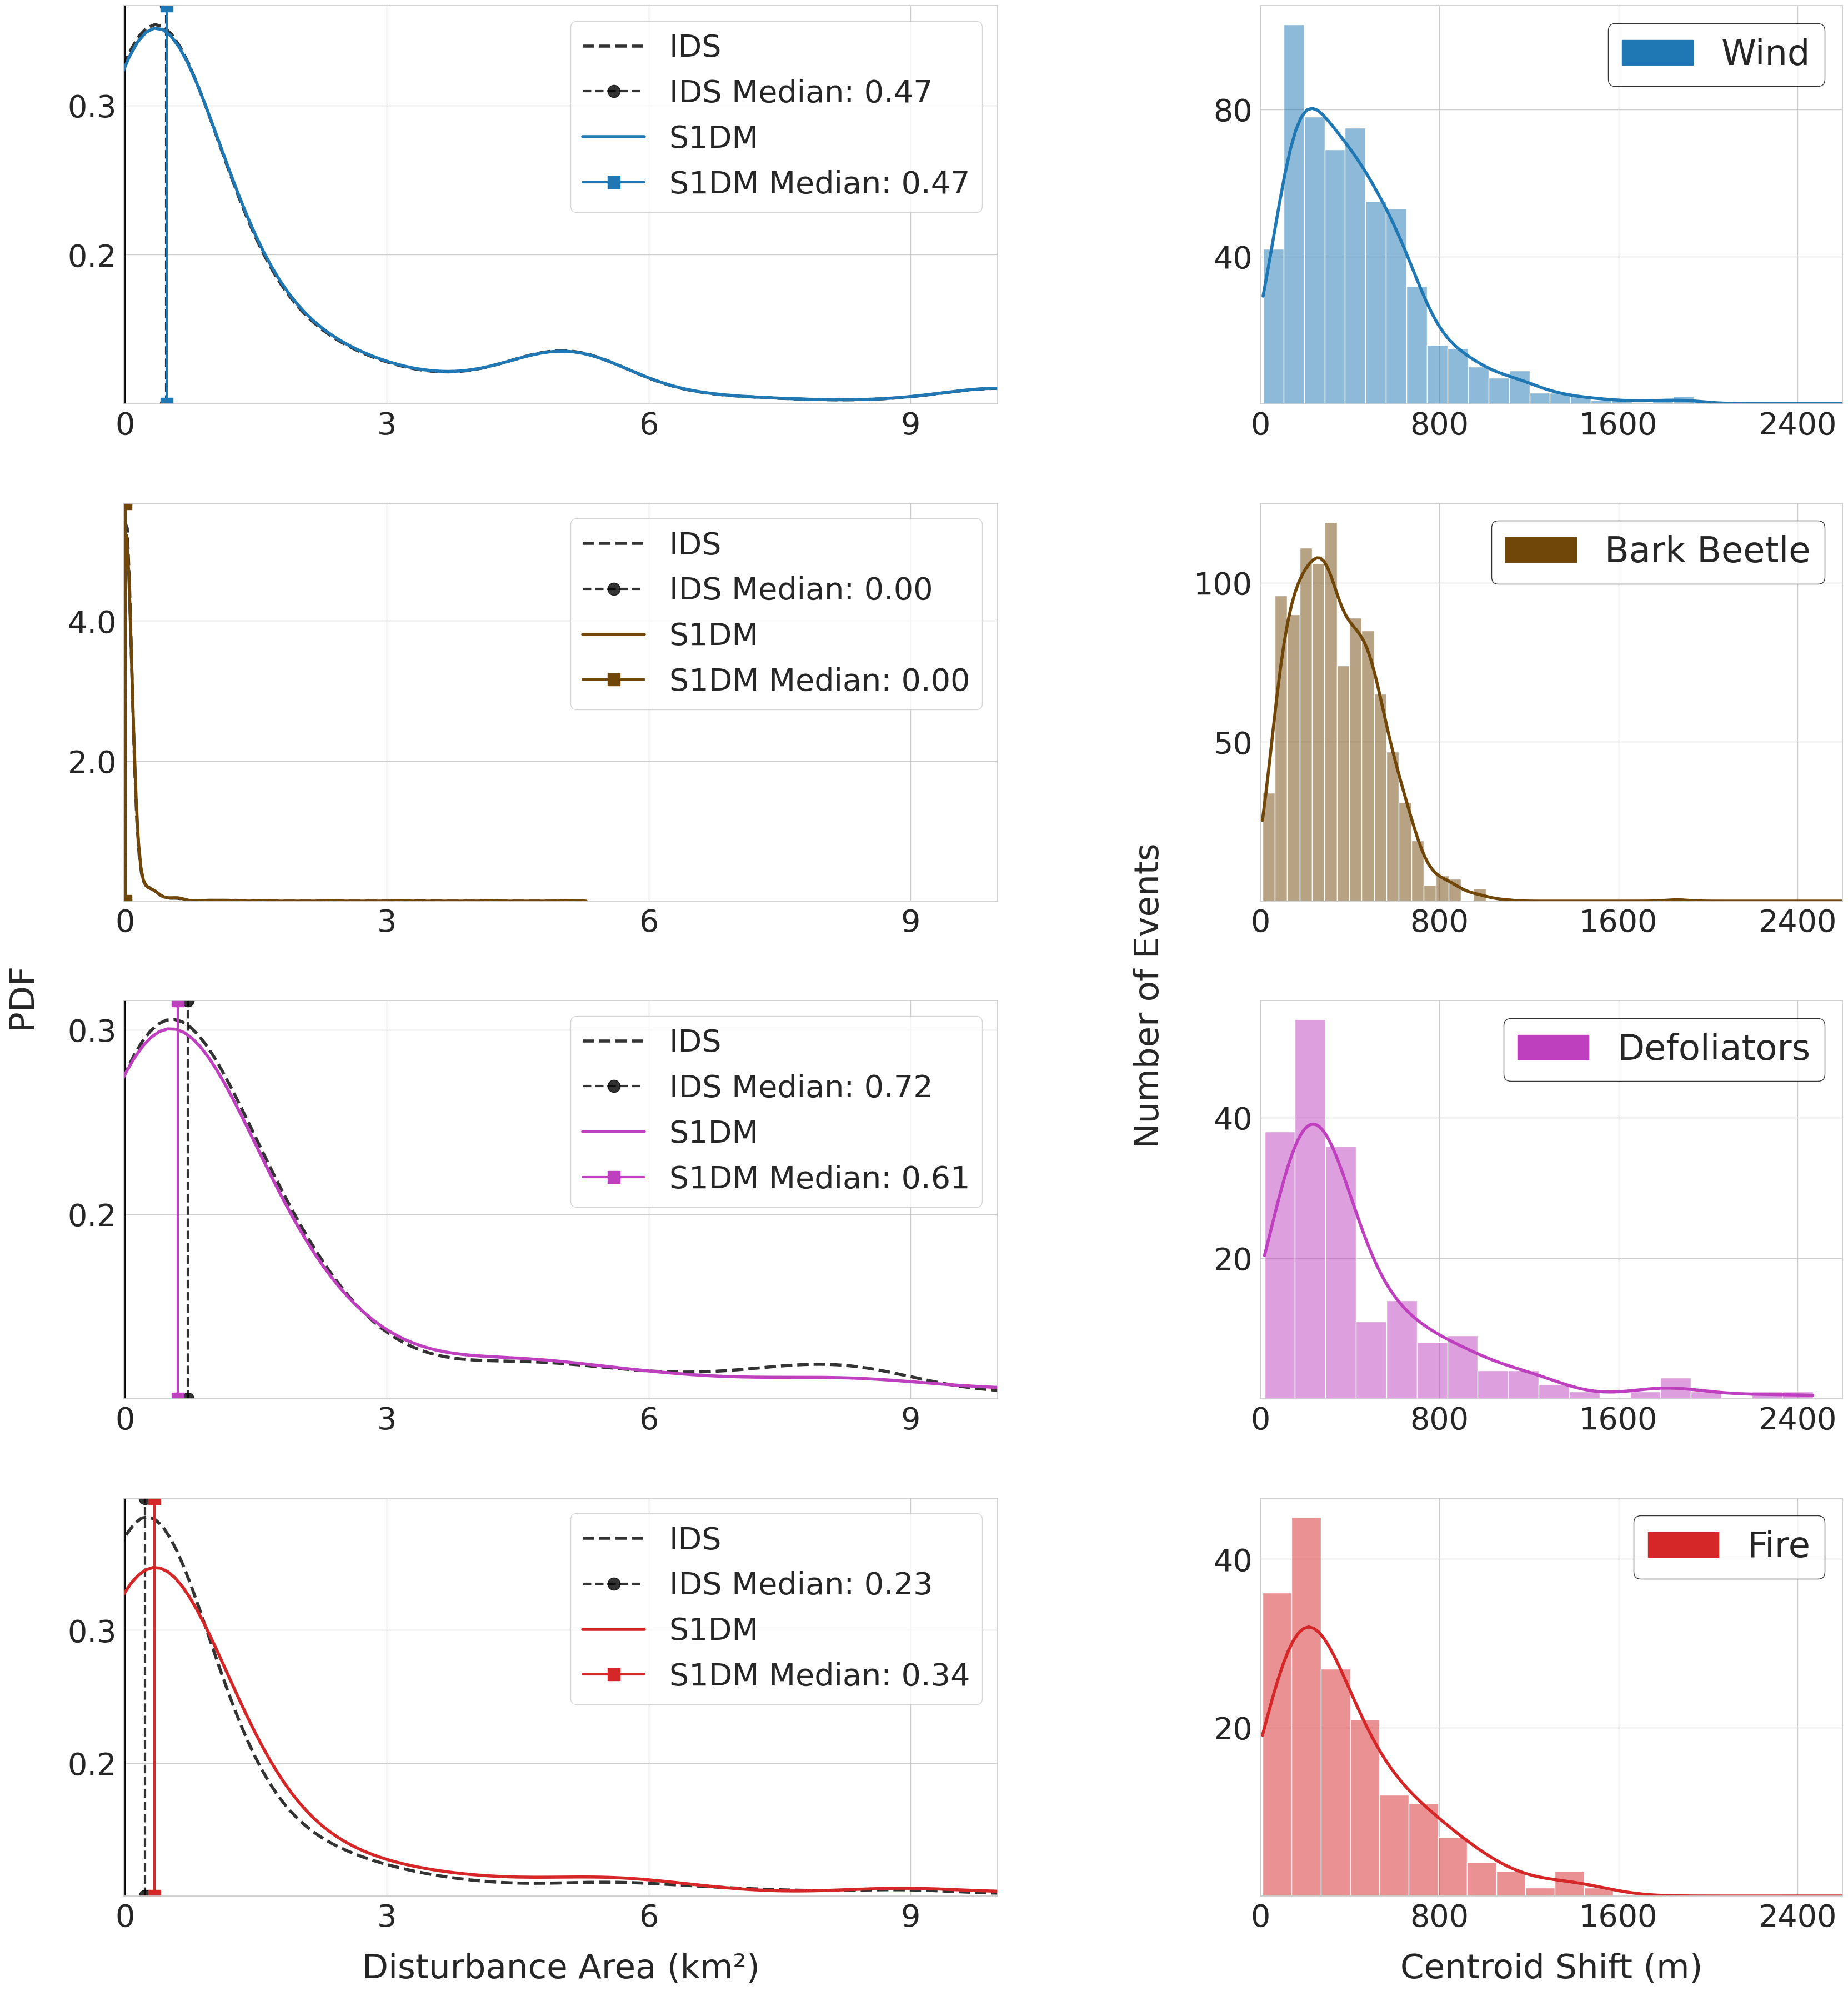

In [17]:
print("Plotting data\n")
# print("Plot 1: Study area ...")
# plot_figure_1(tcc_dataset, mainland, region_8, refdm, tiles_bounds, custom_colors, save_figure_path=figure_study_area_path)
# print("\nPlot 2: Radar reduction potential ...")
# plot_radar_reduction_potential(refdm, ids_gdf, figure_radar_reduction_potential_path )
# # Filter out rows where 'DCA_ID' equals 'drought'
reprojected_refdm = refdm[refdm['DCA_ID'] != 'drought']
print(f"Size of refdm without drougth : {len(reprojected_refdm)}")
# print("\nPlot 3: Disturbance duration ...")
# plot_disturbance_duration(reprojected_refdm, figure_disturbance_duration_path)
# print("\nPlot 4: Size & Position difference ...")
gdf = calculate_size_shift_difference(ids_gdf, reprojected_refdm)
# plot_size_shift_comparison_errorbars(gdf, custom_colors, figure_size_position_change_errrorbar_path)
("\nPlot 5: Size & Position difference ...")
plot_area_size_shift_per_disturbances(gdf, ids_gdf, custom_colors, figure_size_position_change_path)

# Plot Testing

In [16]:
resolution = 10
pixel_size = 512
# Path to grid_file
grid_path = f"{os.getenv('EQUI7_GRIDS')}/grid_equi7_{resolution}_{pixel_size}_region_{region_id}_intersetion.shp"
intersected_gdf_equi7 = gpd.read_file(grid_path)
intersected_gdf_equi7

,FID,geometry
0,0,"POLYGON ((8442880 2908160, 8437760 2908160, 84..."
1,1,"POLYGON ((8448000 2908160, 8442880 2908160, 84..."
2,2,"POLYGON ((8453120 2882560, 8448000 2882560, 84..."
3,3,"POLYGON ((8453120 2908160, 8448000 2908160, 84..."
4,4,"POLYGON ((8458240 2892800, 8453120 2892800, 84..."
...,...,...
972,972,"POLYGON ((10168320 3205120, 10163200 3205120, ..."
973,973,"POLYGON ((10168320 3210240, 10163200 3210240, ..."
974,974,"POLYGON ((10173440 3205120, 10168320 3205120, ..."
975,975,"POLYGON ((10173440 3210240, 10168320 3210240, ..."


In [31]:
ids_cal = calculate_area_and_centroid_meters(ids_gdf)
refdm_cal = calculate_area_and_centroid_meters(refdm)
refdm_cal

,ID_E,geometry,S1_YEAR,IDX_D,S1_TILE,S1CD_INDEX,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,...,O_Year,O_DCA_ID,O_Y_diff,area_km2,Duration,area_meters,square_km,area_convex_meters,area_convex_km,centroid_meters
0,23857,"MULTIPOLYGON (((-91.17667 31.27266, -91.17705 ...",2016,bark_beetle_2016_23857,E087N024T3,0,bark_beetle,2016,8,1,...,NaN,None,NaN,0.025093,1,1.869587e+04,0.018696,1.205271e+05,0.120527,POINT (8879252.362 2590064.255)
1,23858,"MULTIPOLYGON (((-83.74526 35.43746, -83.74545 ...",2016,bark_beetle_2016_23858,E093N030T3,1,bark_beetle,2016,8,1,...,NaN,None,NaN,0.019659,1,1.326835e+04,0.013268,9.521909e+04,0.095219,POINT (9525256.774 3138174.421)
2,23861,"MULTIPOLYGON (((-87.4366 34.31082, -87.4366 34...",2016,fire_2016_23861,E090N027T3,4,fire,2016,8,8,...,NaN,None,NaN,0.170720,2,1.382621e+05,0.138262,8.567282e+05,0.856728,POINT (9203827.104 2963088.198)
3,23862,"MULTIPOLYGON (((-87.42246 34.32613, -87.42226 ...",2016,fire_2016_23862,E090N027T3,5,fire,2016,8,8,...,NaN,None,NaN,0.178635,1,1.237903e+05,0.123790,1.094594e+06,1.094594,POINT (9204679.545 2964632.981)
4,23864,"MULTIPOLYGON (((-87.4368 34.31043, -87.4368 34...",2016,fire_2016_23864,E090N027T3,6,fire,2016,8,8,...,NaN,None,NaN,0.172403,2,1.449080e+05,0.144908,1.004797e+06,1.004797,POINT (9203986.946 2962764.527)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670,26829,"MULTIPOLYGON (((-93.66029 30.34, -93.66029 30....",2019,wind_2020_26829,E084N024T3,2048,wind,2020,8,16,...,NaN,None,NaN,0.059670,3,2.427666e+06,2.427666,1.232018e+07,12.320182,POINT (8644863.43 2472177.051)
1671,26838,"MULTIPOLYGON (((-91.67577 30.33087, -91.67558 ...",2019,defoliators_2020_26838,E087N024T3,2402,defoliators,2020,8,2,...,2018.0,defoliators,-2.0,0.370089,3,9.185916e+05,0.918592,9.957101e+06,9.957101,POINT (8838849.423 2482693.501)
1672,26841,"MULTIPOLYGON (((-90.71421 30.12401, -90.7144 3...",2019,defoliators_2020_26841,E087N024T3,2404,defoliators,2020,8,2,...,2018.0,defoliators,-2.0,0.002638,2,4.035541e+03,0.004036,5.770818e+04,0.057708,POINT (8934334.396 2466268.101)
1673,26843,"MULTIPOLYGON (((-90.72189 30.05762, -90.72246 ...",2019,defoliators_2020_26843,E087N024T3,2405,defoliators,2020,8,2,...,2019.0,defoliators,-1.0,0.008964,3,4.078536e+04,0.040785,1.072961e+07,10.729608,POINT (8934500.73 2460343.719)


In [58]:
gdf = calculate_size_shift_difference(ids_cal, refdm)
gdf

,ID_E,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,ID_O,O_Year,O_DCA_ID,O_Y_diff,IDX_D,area_km2,geometry,area_meters,square_km,area_convex_meters,area_convex_km,centroid_meters,centroid_shift_m,size_difference_km2,size_difference_ref_km2
0,23857,bark_beetle,2016,8,1,None,NaN,None,NaN,bark_beetle_2016_23857,0.037331,"POLYGON ((-91.17886 31.27813, -91.17918 31.277...",2.781384e+04,0.027814,3.595914e+04,0.035959,POINT (8879264.017 2590200.584),136.826608,0.009118,-0.009118
1,23858,bark_beetle,2016,8,1,None,NaN,None,NaN,bark_beetle_2016_23858,0.044889,"POLYGON ((-83.74712 35.43908, -83.74695 35.439...",3.029683e+04,0.030297,3.029683e+04,0.030297,POINT (9525087.186 3138095.058),187.239559,0.017028,-0.017028
2,23861,fire,2016,8,8,None,NaN,None,NaN,fire_2016_23861,0.106956,"POLYGON ((-87.43671 34.31719, -87.43684 34.317...",7.414156e+04,0.074142,8.128313e+04,0.081283,POINT (9203579.233 2963083.223),247.920986,-0.064121,0.064121
3,23862,fire,2016,8,8,None,NaN,None,NaN,fire_2016_23862,0.081436,"POLYGON ((-87.41908 34.33236, -87.41911 34.332...",5.643310e+04,0.056433,6.396656e+04,0.063967,POINT (9204772.572 2964676.073),102.523516,-0.067357,0.067357
4,23864,fire,2016,8,8,None,NaN,None,NaN,fire_2016_23864,0.198056,"POLYGON ((-87.43419 34.31322, -87.43322 34.313...",1.373105e+05,0.137310,1.392958e+05,0.139296,POINT (9204072.016 2962555.318),225.843939,-0.007597,0.007597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1674,26225,defoliators,2019,8,2,24480,2018.0,defoliators,-1.0,defoliators_2019_26225,0.740588,"POLYGON ((-91.53086 30.33864, -91.53078 30.338...",5.637613e+05,0.563761,7.625963e+05,0.762596,POINT (8852104.809 2482595.687),2845.080057,-7.755223,7.755223
1675,26838,defoliators,2020,8,2,24490,2018.0,defoliators,-2.0,defoliators_2020_26838,10.858748,"POLYGON ((-91.65263 30.3493, -91.64905 30.3457...",8.263617e+06,8.263617,8.308048e+06,8.308048,POINT (8838855.503 2482867.932),174.537083,7.345025,-7.345025
1676,26838,defoliators,2020,8,2,26176,2019.0,defoliators,-1.0,defoliators_2020_26838,10.858748,"POLYGON ((-91.65263 30.3493, -91.64905 30.3457...",8.263617e+06,8.263617,8.308048e+06,8.308048,POINT (8838855.503 2482867.932),174.537083,7.345025,-7.345025
1677,26841,defoliators,2020,8,2,24454,2018.0,defoliators,-2.0,defoliators_2020_26841,8.470990,"POLYGON ((-90.69715 30.13595, -90.69038 30.129...",6.479931e+06,6.479931,6.500954e+06,6.500954,POINT (8934628.932 2466347.281),304.993241,6.475896,-6.475896


In [308]:
def plot_size_shift_comparison_errorbars_convex(gdf, custom_colors, save_path):

    # Get the default colors from 'tab10' palette for the rest of the disturbance types
    default_palette = sns.color_palette('tab10', n_colors=10)
    default_colors = [color for color in default_palette if color not in custom_colors.values()]

    # Combine the custom colors with the default colors
    custom_palette = [custom_colors.get(label, default_colors.pop(0)) for label in gdf['DCA_ID'].unique()]

    # # Multiply 'size_difference' by 100
    # gdf['size_difference_scaled'] = gdf['size_difference'] * 1000
    # # Multiply 'centroid_shift' by 100
    # gdf['centroid_shift_scaled'] = gdf['centroid_shift'] * 100

    # Calculate medians and quantiles for each disturbance type
    grouped = gdf.groupby('DCA_ID').agg({
        'centroid_shift_m': ['median', lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)],
        'convex_size_difference_ref_km2': ['median', lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)]
    }).reset_index()

    # Flatten the column names after aggregation
    grouped.columns = ['DCA_ID', 'centroid_shift_median', 'centroid_shift_q25', 'centroid_shift_q75', 'size_diff_median', 'size_diff_q25', 'size_diff_q75']

    # Set Seaborn style
    sns.set(style="whitegrid")

    plt.figure(figsize=(10,6))

    # Show quadrant lines
    plt.axhline(0, color='black', linewidth=2.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=2.5, linestyle='--')


    # Plot the median values and IQR with shaded regions
    for i, row in grouped.iterrows():
        plt.scatter(
            row['centroid_shift_median'],
            row['size_diff_median'],
            color=custom_colors.get(row['DCA_ID'], 'grey'),
            s=300,  # Larger scatter points
            edgecolor='w',
            alpha=0.7,
            label=row['DCA_ID']
        )
        plt.errorbar(
            row['centroid_shift_median'],
            row['size_diff_median'],
            xerr=[[row['centroid_shift_median'] - row['centroid_shift_q25']], [row['centroid_shift_q75'] - row['centroid_shift_median']]],
            yerr=[[row['size_diff_median'] - row['size_diff_q25']], [row['size_diff_q75'] - row['size_diff_median']]],
            fmt='o',
            color=custom_colors.get(row['DCA_ID'], 'grey'),
            alpha=0.8,
            capsize=10,  # Larger error bar caps
            capthick=3.5,
            linewidth=3.5  # Thicker error bar lines
        )

    # Customize the plot
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.axvline(0, color='grey', linestyle='--', linewidth=1)
    plt.xlabel('Position Shift (m)', fontsize=20)
    plt.ylabel('Size Difference (km²)', fontsize=20)
    plt.title('Area and Position Changes per Disturbance Types', fontsize=26, pad=20)

    # Set legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    legend = plt.legend(by_label.values(), by_label.keys(), title='Disturbance Types', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)
    legend.set_title('Disturbance Types', prop={'size': 18})  # Set legend title size

    # Set decimal tick labels
    plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # Increase tick label size
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    plt.tight_layout()
   
    #plt.savefig(save_path, bbox_inches='tight')
    plt.show()

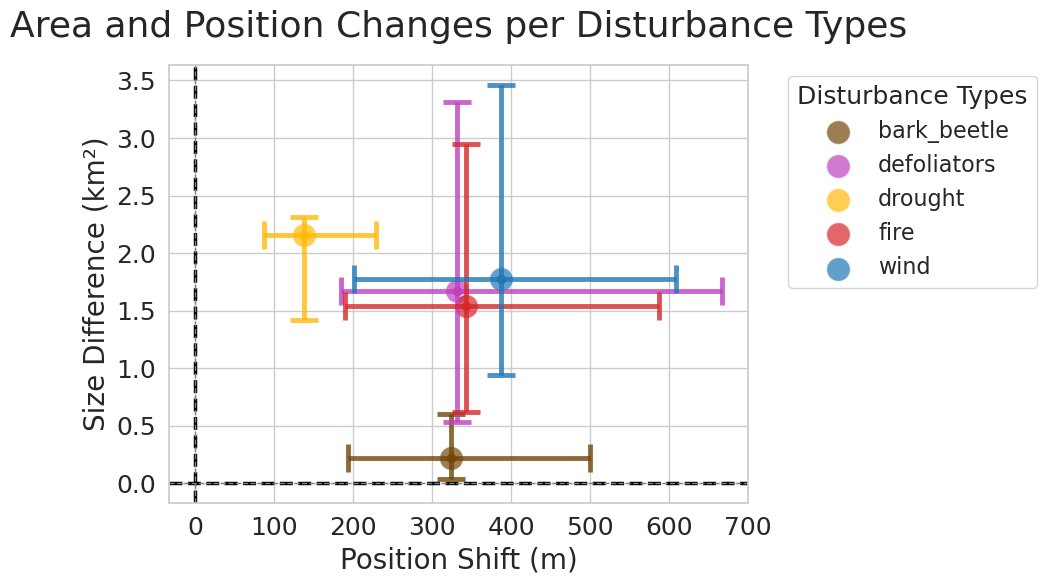

In [309]:
plot_size_shift_comparison_errorbars_convex(gdf, custom_colors, figure_size_position_change_errrorbar_path)

In [59]:
gdf_wind = gdf[gdf['DCA_ID'] == 'wind']
gdf_wind


,ID_E,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,ID_O,O_Year,O_DCA_ID,O_Y_diff,IDX_D,area_km2,geometry,area_meters,square_km,area_convex_meters,area_convex_km,centroid_meters,centroid_shift_m,size_difference_km2,size_difference_ref_km2
41,24000,wind,2016,8,16,None,NaN,None,NaN,wind_2016_24000,1.044676,"POLYGON ((-87.52951 35.351, -87.53172 35.34941...",7.048583e+05,0.704858,2.073298e+06,2.073298,POINT (9183340.982 3077407.845),214.005571,-2.865686,2.865686
61,24041,wind,2017,8,16,None,NaN,None,NaN,wind_2017_24041,0.567426,"MULTIPOLYGON (((-90.41183 32.41636, -90.41168 ...",4.116914e+05,0.411691,7.645684e+05,0.764568,POINT (8943990.724 2722493.245),524.700983,-0.081348,0.081348
64,24044,wind,2017,8,16,None,NaN,None,NaN,wind_2017_24044,0.493280,"POLYGON ((-89.88743 33.05325, -89.88727 33.055...",3.525076e+05,0.352508,4.112592e+05,0.411259,POINT (8987993.102 2797375.95),127.630496,-0.679168,0.679168
65,24047,wind,2017,8,16,None,NaN,None,NaN,wind_2017_24047,0.332512,"POLYGON ((-89.54414 33.54282, -89.54154 33.542...",2.348179e+05,0.234818,2.935225e+05,0.293522,POINT (9015386.541 2854428.77),184.224595,-0.086906,0.086906
68,24050,wind,2017,8,16,None,NaN,None,NaN,wind_2017_24050,0.824142,"POLYGON ((-89.7885 33.1578, -89.78833 33.15995...",5.874129e+05,0.587413,1.116086e+06,1.116086,POINT (8996330.959 2810260.505),272.195303,0.367868,-0.367868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657,26003,wind,2019,8,16,25864,2018.0,wind,-1.0,wind_2019_26003,0.042861,"POLYGON ((-85.0747 31.00434, -85.07478 31.0069...",3.223671e+04,0.032237,3.223671e+04,0.032237,POINT (9473904.28 2629505.728),805.160146,-0.612282,0.612282
1658,26004,wind,2019,8,16,25865,2018.0,wind,-1.0,wind_2019_26004,0.181492,"POLYGON ((-85.07489 31.00412, -85.07493 31.000...",1.365145e+05,0.136515,1.377768e+05,0.137777,POINT (9473694.209 2629124.577),156.499727,0.099175,-0.099175
1659,26005,wind,2019,8,16,25866,2018.0,wind,-1.0,wind_2019_26005,0.680682,"POLYGON ((-85.12983 31.19911, -85.12897 31.203...",5.096001e+05,0.509600,5.863572e+05,0.586357,POINT (9465820.237 2650642.024),671.605606,-0.071060,0.071060
1660,26006,wind,2019,8,16,25867,2018.0,wind,-1.0,wind_2019_26006,1.677880,"POLYGON ((-85.12941 31.20939, -85.12944 31.206...",1.256094e+06,1.256094,1.666348e+06,1.666348,POINT (9465059.144 2650773.13),1077.982249,0.640157,-0.640157


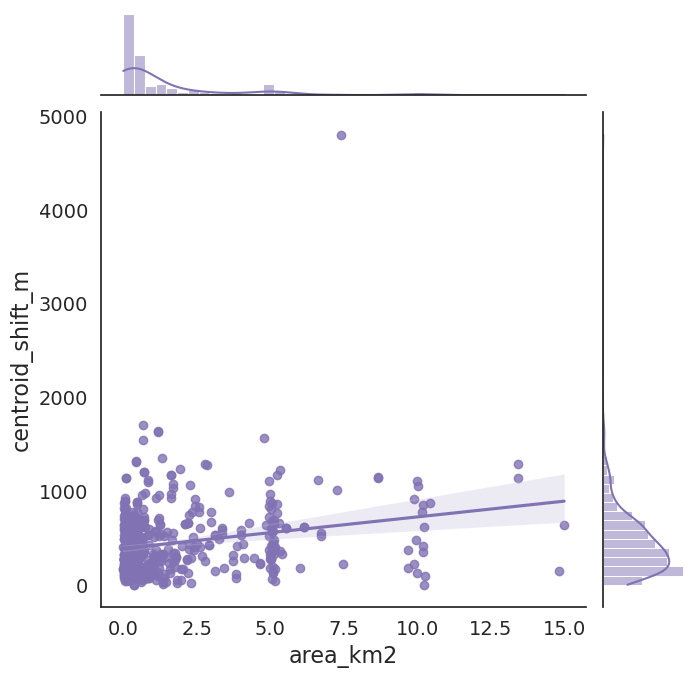

In [137]:
gdf_wind = gdf[gdf['DCA_ID'] == 'wind']
gdf_wind
g = sns.jointplot(x="area_km2", y="centroid_shift_m", data=gdf_wind,
                  kind="reg",
                  color="m", height=7)

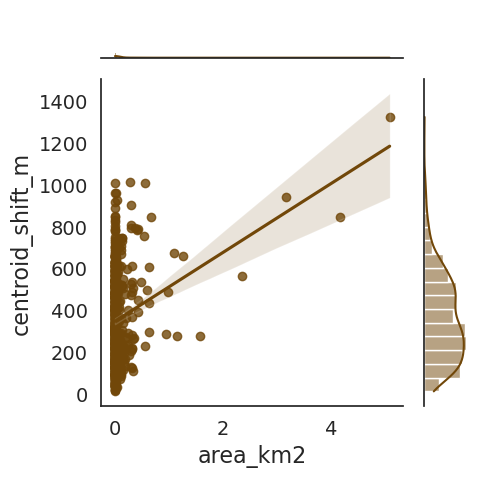

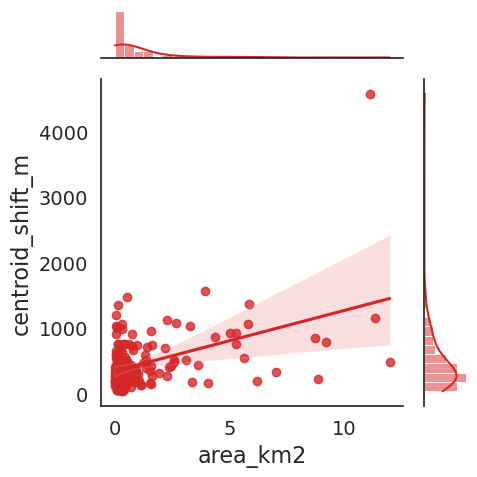

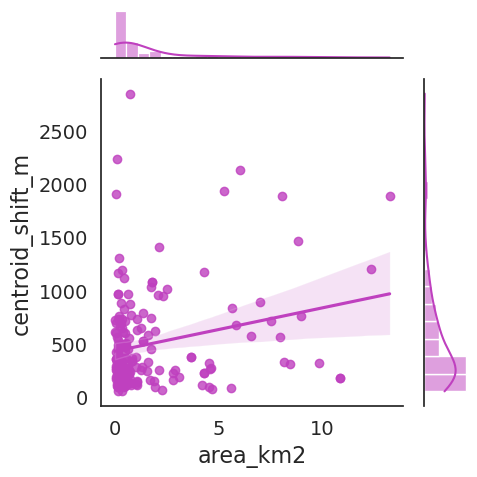

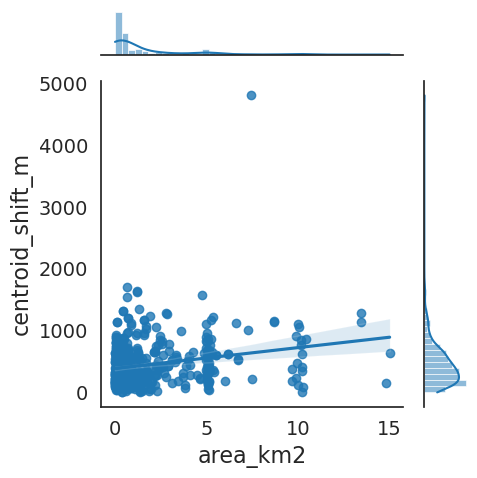

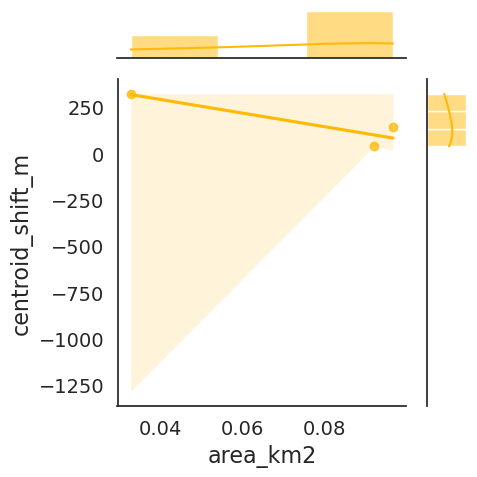

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get unique disturbance types
dca_ids = gdf['DCA_ID'].unique()

# Loop through each disturbance type and create a joint plot with histograms
for dca_id in dca_ids:
    
    gdf_subset = gdf[gdf['DCA_ID'] == dca_id]
    color = custom_colors[dca_id]  # Get the correct color

    # Create the joint plot for each disturbance type
    g = sns.jointplot(x="area_km2", y="centroid_shift_m", data=gdf_subset,
                       kind="reg", color=color, height=5)

    # Move the joint plot to the appropriate position in the main figure
    g.fig.set_size_inches(5, 5)  # Set size for individual plots
    g.fig.tight_layout()           # Adjust layout



/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


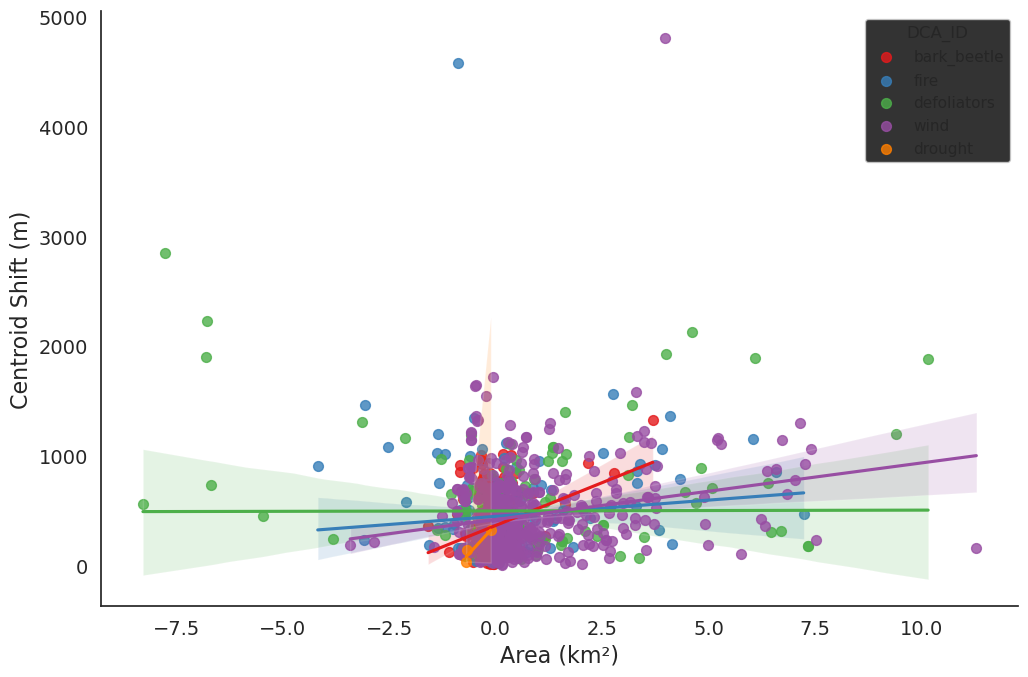

In [101]:
unique_dca_ids = gdf['DCA_ID'].nunique()  # Number of unique DCA_IDs
markers = ["o", "s", "D", "^"][:unique_dca_ids]  # Adjust markers to the number of unique DCA_IDs

g = sns.lmplot(x="size_difference_km2", y="centroid_shift_m", data=gdf, 
               hue="DCA_ID", 
               height=7, aspect=1.5, 
               palette="Set1",  
               markers="o",  # List of markers for each DCA_ID
               scatter_kws={'s':50},
               legend_out=False)

g.set_axis_labels("Area (km²)", "Centroid Shift (m)") # Set axis labels


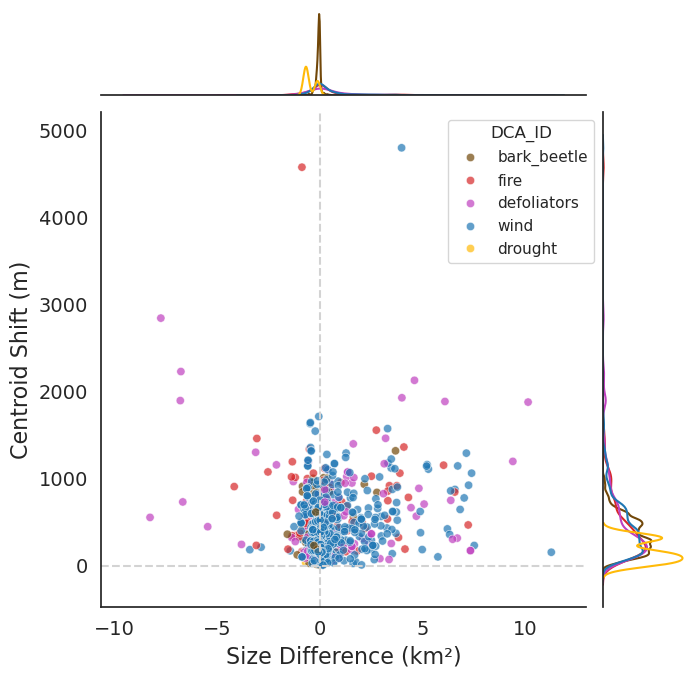

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the JointGrid
g = sns.JointGrid(data=gdf, x="size_difference_km2", y="centroid_shift_m", height=7)

# Add the scatter plot with hue for DCA_ID using custom colors and increased transparency
sns.scatterplot(x="size_difference_km2", y="centroid_shift_m", 
                data=gdf, hue="DCA_ID", ax=g.ax_joint, 
                palette=custom_colors, alpha=0.7)  # Adjust alpha for transparency

# Add the marginal KDE plots for each DCA_ID with custom colors
for dca_id in gdf['DCA_ID'].unique():
    subset = gdf[gdf['DCA_ID'] == dca_id]
    sns.kdeplot(x=subset['size_difference_km2'], ax=g.ax_marg_x, label=dca_id, 
                bw_adjust=0.5, color=custom_colors[dca_id])
    sns.kdeplot(y=subset['centroid_shift_m'], ax=g.ax_marg_y, label=dca_id, 
                bw_adjust=0.5, color=custom_colors[dca_id])

# Add dashed lines at x=0 and y=0
g.ax_joint.axhline(0, color='lightgray', linestyle='--')
g.ax_joint.axvline(0, color='lightgray', linestyle='--')

# Adjust the legend and layout
g.ax_joint.legend(title="DCA_ID", bbox_to_anchor=(0.70, 1), loc='upper left', frameon=True)
plt.setp(g.ax_joint.legend_.get_frame(), facecolor='white')  # Set legend background to white

# Set axis labels
g.set_axis_labels("Size Difference (km²)", "Centroid Shift (m)")

plt.show()


/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Us

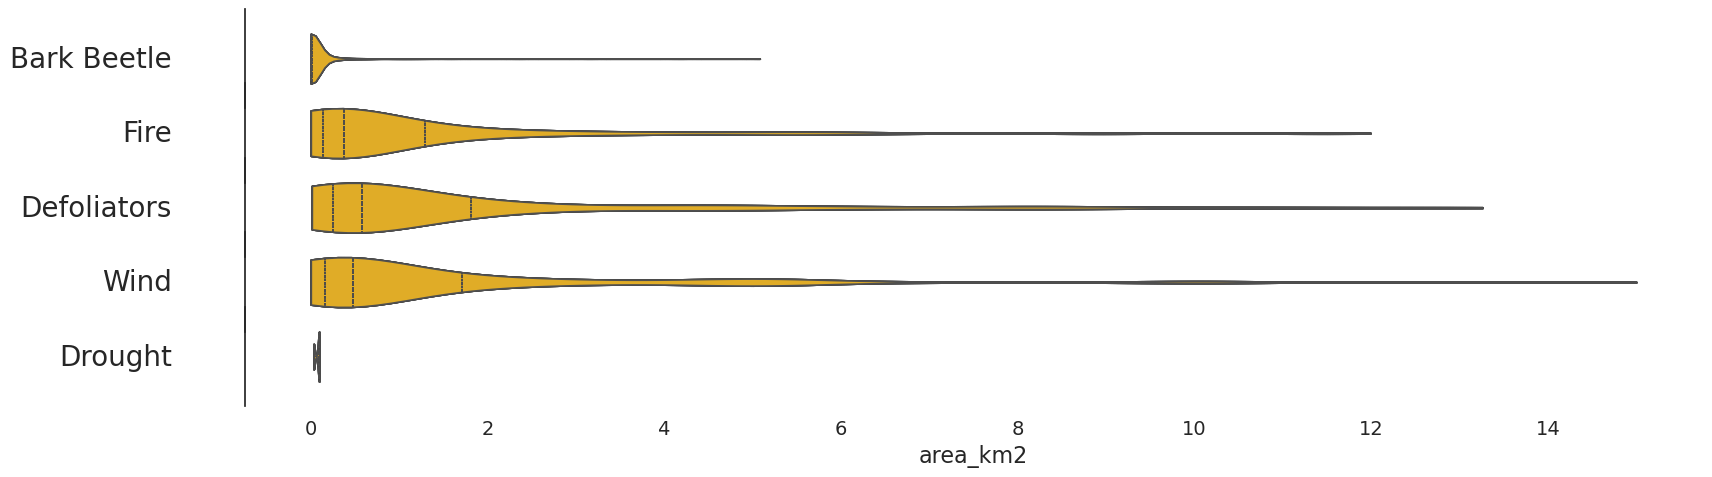

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure DCA_ID is a string and drop missing values
gdf['DCA_ID'] = gdf['DCA_ID'].astype(str)
gdf = gdf.dropna(subset=['DCA_ID', 'area_km2'])

# Define custom colors
custom_colors = {
    "wind": "#1f77b4", 
    "fire": "#d62728", 
    "defoliators": "#BF40BF", 
    "drought": "#FFBA08", 
    "bark_beetle": "#714709"
}

# Get the unique DCA_IDs to define the order
dca_ids = gdf['DCA_ID'].unique()

# Initialize the FacetGrid object
g = sns.FacetGrid(gdf, row="DCA_ID", aspect=15, height=1, row_order=dca_ids)

# Clear default titles
g.set_titles("")

# Draw the violin plots for area_km2 without outliers, using custom colors
for dca_id in dca_ids:
    subset = gdf[gdf['DCA_ID'] == dca_id]  # Filter data for each DCA_ID
    g.map(sns.violinplot, "area_km2", inner="quartile", bw_method=0.3, width=0.5, cut=0,
          color=custom_colors[dca_id], data=subset)

# Set subplots to overlap slightly
g.figure.subplots_adjust(hspace=-.25)

# Remove the default y-ticks
g.set(yticks=[], ylabel="")

# Add formatted DCA_ID labels on the left spine
for ax, label in zip(g.axes.flatten(), dca_ids):
    formatted_label = format_label(label)
    ax.text(-0.05, 0.5, formatted_label, ha='right', va='center', transform=ax.transAxes, fontsize=20)

# Clean up the spines
g.despine(bottom=True, left=False)

plt.show()


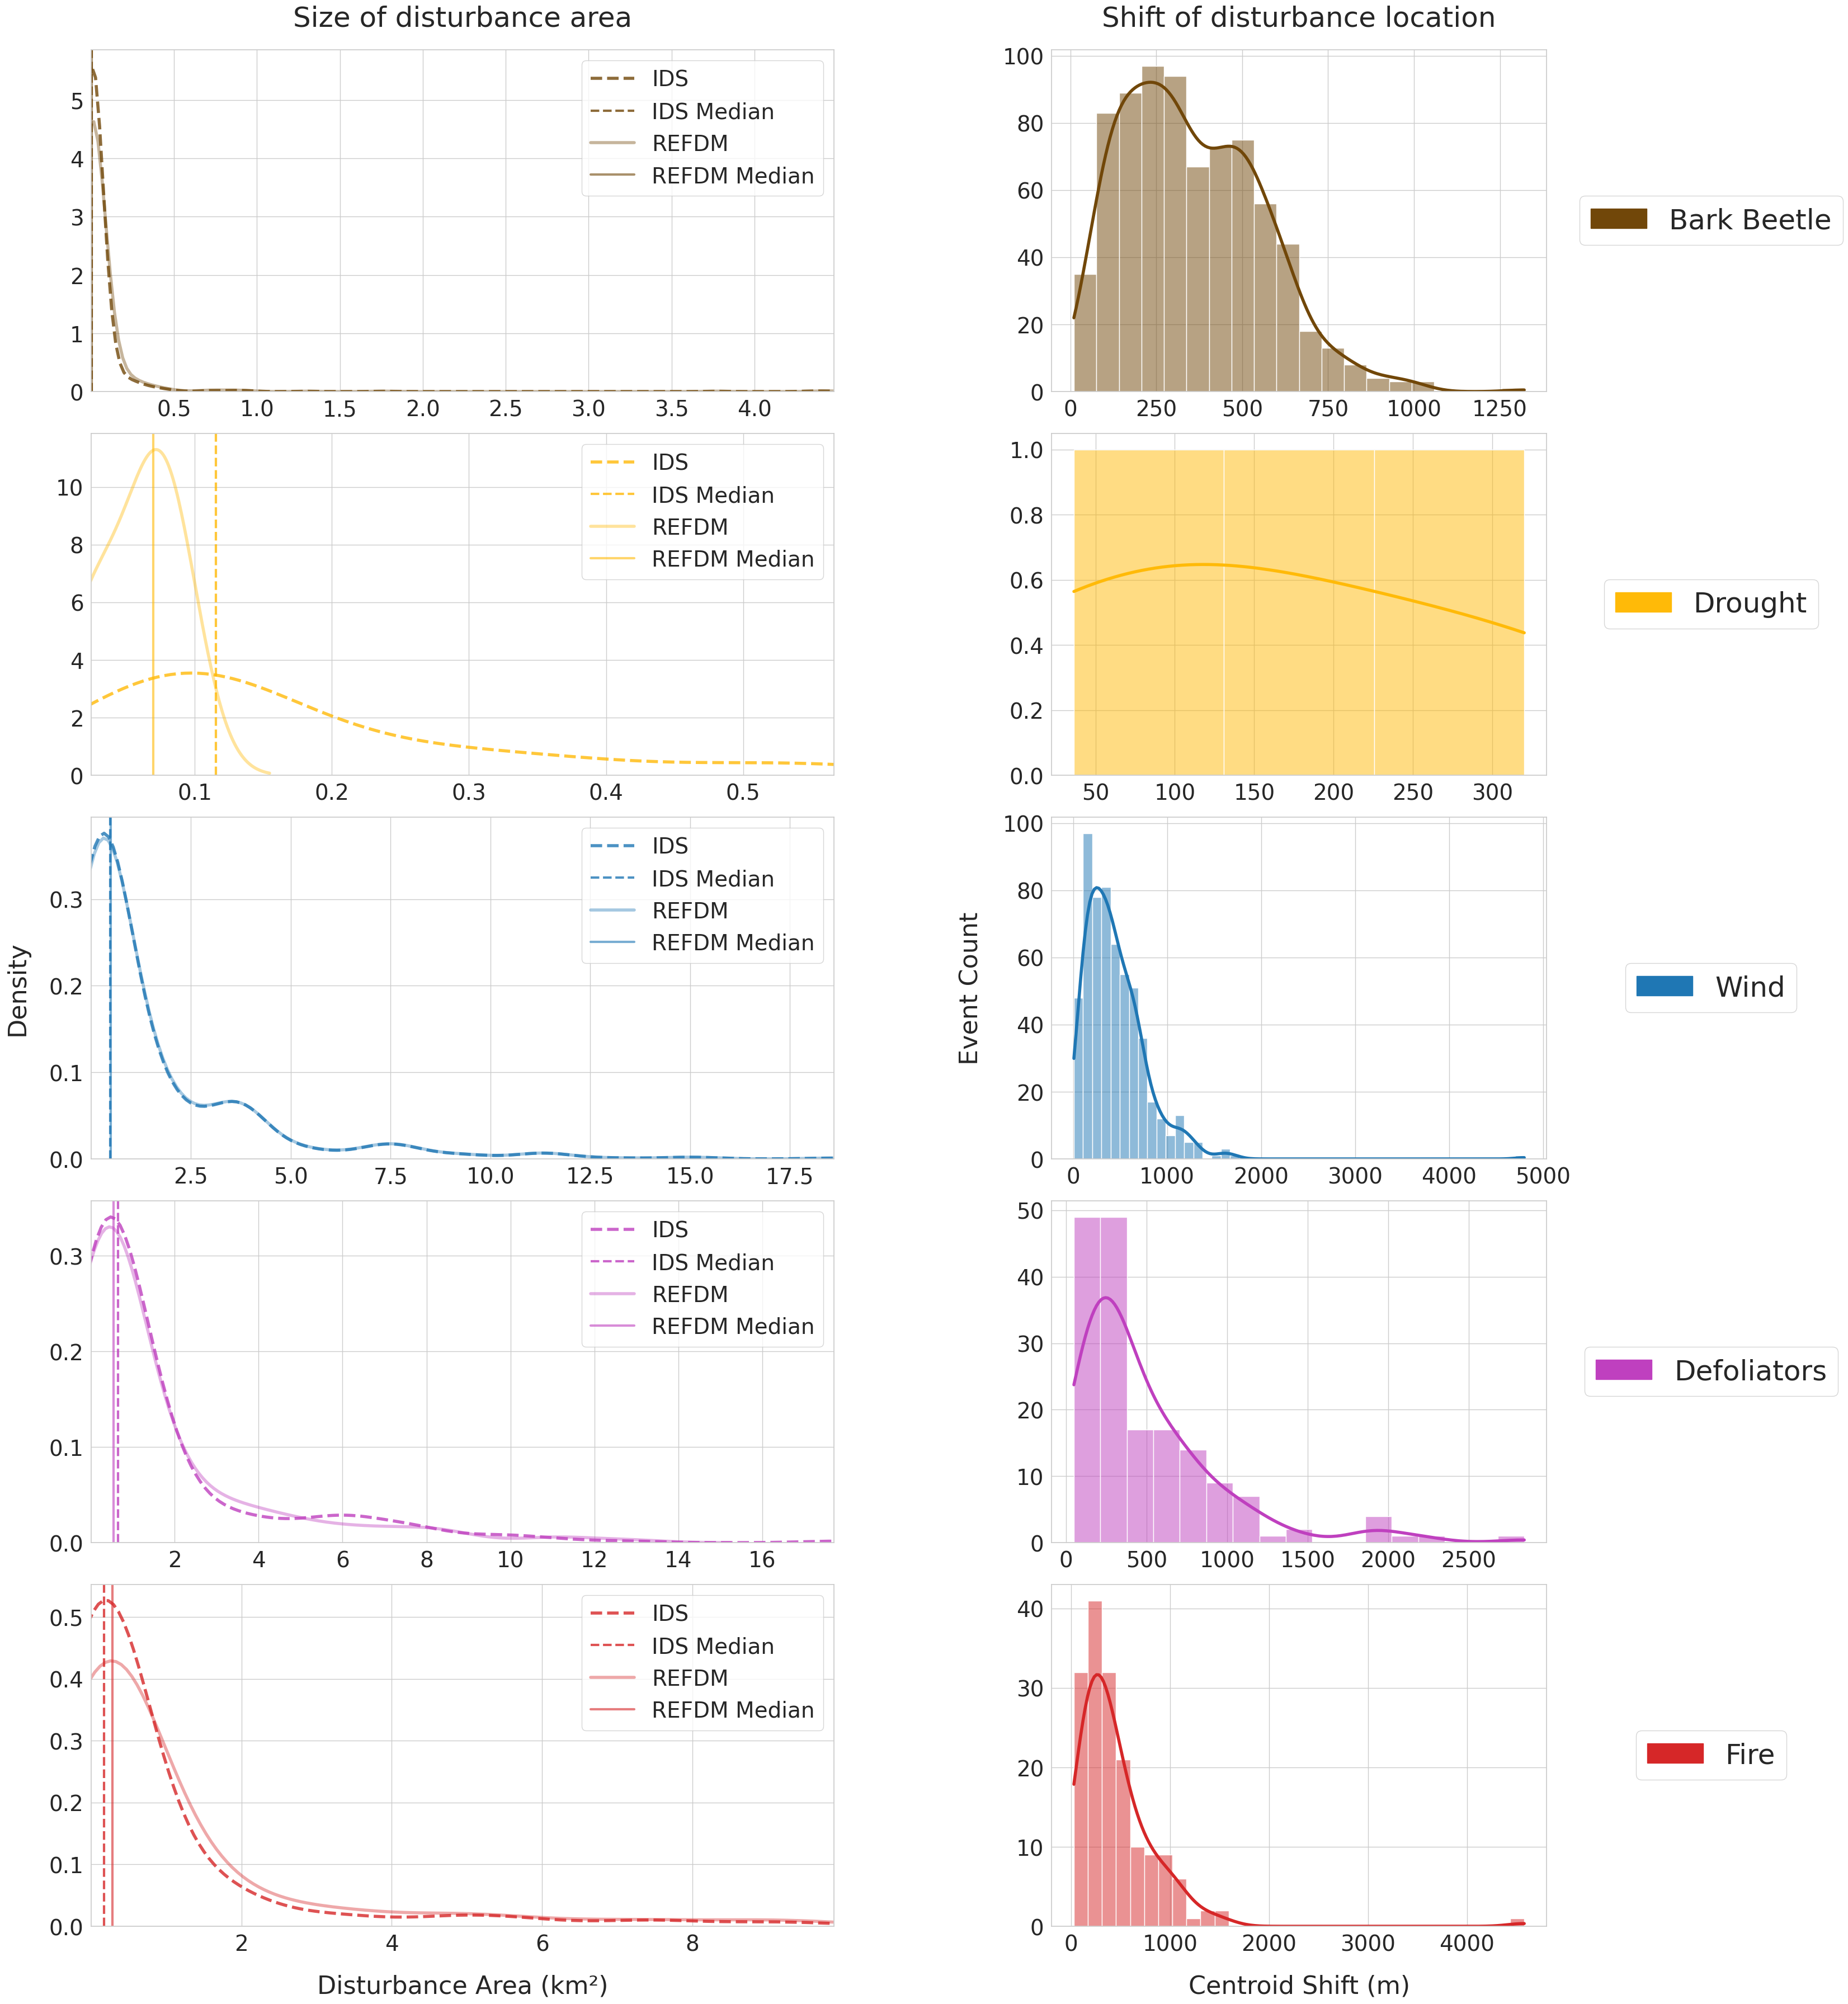

In [311]:
def plot_combined_convex_areasize_shift(gdf, ids, custom_colors, save_path):
    # Define the order of the categories
    category_order = ['bark_beetle', 'drought', 'wind', 'defoliators', 'fire']

    # Get the default colors from 'tab10' palette for the rest of the disturbance types
    default_palette = sns.color_palette('tab10', n_colors=10)
    default_colors = [color for color in default_palette if color not in custom_colors.values()]

    # Combine the custom colors with the default colors
    custom_palette = {label: custom_colors.get(label, default_colors.pop(0)) for label in category_order}

    # Set Seaborn style
    sns.set(style="whitegrid")

    # Create a grid with 5 rows and 4 columns for the plots
    fig, axs = plt.subplots(5, 4, figsize=(35, 40), gridspec_kw={'width_ratios': [3, 0.05, 2, 0.5]})

    # Define font sizes
    fontsize_supertitle = 44
    fontsize_legend = 36
    fontsize_title = 36
    fontsize_label = 32  # Reduced slightly for clarity
    fontsize_tick = 28
    padding_label = 25  # Slightly smaller padding
    padding_title = 30

    for i, category in enumerate(category_order):
        
        # Create combined data for violin plots
        combined_data = pd.concat([
            ids[ids['DCA_ID'] == category][['DCA_ID', 'area_convex_km']].assign(Source='IDS'),
            gdf[gdf['DCA_ID'] == category][['DCA_ID', 'area_convex_km']].assign(Source='REFDM')
        ])

        # Violin plot for size differences (GDF and IDS)
        ax = axs[i, 0]

        # Filter data for the current category (REFDM and IDS)
        data_refdm = combined_data[(combined_data['Source'] == 'REFDM') & (combined_data['DCA_ID'] == category)]
        data_ids = combined_data[(combined_data['Source'] == 'IDS') & (combined_data['DCA_ID'] == category)]
        
        # Calculate the 10th and 90th percentiles for the x-axis limits
        lower_percentile = np.percentile(combined_data['area_convex_km'], 0)
        upper_percentile = np.percentile(combined_data['area_convex_km'], 100)
        
        # Add median lines in the same hue as corresponding KDE lines
        median_refdm = np.median(data_refdm['area_convex_km'])
        median_ids = np.median(data_ids['area_convex_km'])

        # Plot KDE plot for IDS
        sns.kdeplot(
            data=data_ids['area_convex_km'],
            color=custom_palette[category],
            ax=ax,
            common_norm=True,
            linewidth=4,  # Adjust line width
            label='IDS',
            alpha=0.8,  # Adjust transparency for IDS plot
            linestyle='--',  # Dashed line style for IDS
        )

        ax.axvline(x=median_ids, color=custom_palette[category], linestyle='--', linewidth=3, alpha=0.8, label='IDS Median')

        # Plot KDE plot for REFDM
        sns.kdeplot(
            data=data_refdm['area_convex_km'],
            color=custom_palette[category],
            ax=ax,
            common_norm=True,
            linewidth=4,  # Adjust line width
            label='REFDM',
            alpha=0.4,  # Adjust transparency for REFDM plot
            linestyle='-',  # Solid line style for REFDM
        )

        ax.axvline(x=median_refdm, color=custom_palette[category], linestyle='-', linewidth=3, alpha=0.6, label='REFDM Median')
        ax.legend(fontsize=fontsize_tick)

        # Ensure y-axis starts from 0 and ends at 1
        ax.set_ylim(0)
        ax.set_xlim(lower_percentile, upper_percentile)  # Set x-axis limit based on percentiles
        ax.tick_params(axis='x', labelsize=fontsize_tick)
        ax.tick_params(axis='y', labelsize=fontsize_tick)

        if i == len(category_order) - 1:  # Only set x-label for the bottom row
            ax.set_xlabel('Disturbance Area (km²)', fontsize=fontsize_label, labelpad=padding_label)  # Set x-axis label
        else:
            ax.set_xlabel('', labelpad=padding_label)

        if i == 2:  # Only set y-label for the third row
            ax.set_ylabel('Density', fontsize=fontsize_label, labelpad=padding_label)
        else:
            ax.set_ylabel(' ', fontsize=fontsize_label, labelpad=padding_label)
        
        if i == 0:  # Only set y-label for the first column
            ax.set_title('Size of disturbance area', fontsize=fontsize_title, pad=padding_title)

        # Distribution plot for centroid shifts
        ax = axs[i, 2]
        sns.histplot(
            data=gdf[gdf['DCA_ID'] == category],
            x='centroid_shift_m',
            kde=True,
            line_kws={'linewidth': 4},  # Adjust the line width of the KDE curve
            color=custom_palette[category],
            ax=ax
        )
        ax.tick_params(axis='x', labelsize=fontsize_tick)
        ax.tick_params(axis='y', labelsize=fontsize_tick)

        if i == 2:  # Only set y-label for the third row
            ax.set_ylabel('Event Count', fontsize=fontsize_label, labelpad=padding_label)
        else:
            ax.set_ylabel(' ', fontsize=fontsize_label, labelpad=padding_label)
        
        if i == len(category_order) - 1:  # Only set x-label for the bottom row
            ax.set_xlabel('Centroid Shift (m)', fontsize=fontsize_label, labelpad=padding_label)  # Set x-axis label
        else:
            ax.set_xlabel('')

        if i == 0:  # Only set y-label for the first column
            ax.set_title('Shift of disturbance location', fontsize=fontsize_title, pad=padding_title)

        # Custom legend in fourth column
        ax = axs[i, 3]
        ax.legend(handles=[mpatches.Patch(color=custom_palette[category], label=format_label(category))], loc='center', fontsize=fontsize_legend)
        ax.axis('off')

        axs[i, 1].axis('off')

    # Set the overall title and adjust layout
    #fig.suptitle('Spatial Positiand Size Comparison Between IDS and REFDM', fontsize=fontsize_supertitle, y=0.96)
    
    # Adjust the layout to place shared labels
    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
    #plt.savefig(save_path, bbox_inches='tight')
    # Show plot (or save if needed)
    plt.show()

plot_combined_convex_areasize_shift(gdf, ids, custom_colors, save_path=None)

# Testing Downloding Sucess:

In [13]:
import os

# Define the path to your main folder
og_folder = '/net/projects/forexd/WP1/Data/S2_Cubes_IDS_R8/'

# Function to calculate folder size
def get_folder_size(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            # Skip if the file is broken (symlinks)
            if os.path.exists(fp):
                total_size += os.path.getsize(fp)
    return total_size

# Iterate through the subfolders in the og_folder
for folder_name in os.listdir(og_folder):
    folder_path = os.path.join(og_folder, folder_name)
    
    # Check if it's a folder
    if os.path.isdir(folder_path):
        folder_size_bytes = get_folder_size(folder_path)
        folder_size_gb = folder_size_bytes / (1024 ** 3)  # Convert bytes to GB
        
        # Check if the folder size is less than 1 GB
        if folder_size_gb < 1:
            print(f"Folder: {folder_name}, Size: {folder_size_gb:.2f} GB")


Folder: 43_10_512_20152024_equi7_NA.zarr, Size: 0.48 GB
Folder: 45_10_512_20152024_equi7_NA.zarr, Size: 0.09 GB
Folder: 479_10_512_20152024_equi7_NA.zarr, Size: 0.06 GB
Folder: 125_10_512_20152024_equi7_NA.zarr, Size: 0.04 GB
Folder: 114_10_512_20152024_equi7_NA.zarr, Size: 0.03 GB
Folder: 126_10_512_20152024_equi7_NA.zarr, Size: 0.04 GB
Folder: 242_10_512_20152024_equi7_NA.zarr, Size: 0.27 GB
Folder: 115_10_512_20152024_equi7_NA.zarr, Size: 0.04 GB
Folder: 856_10_512_20152024_equi7_NA.zarr, Size: 0.53 GB


In [14]:
# Open the Zarr file as an xarray dataset
# Load the Environment variables
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)
idx = 99
path = f"{os.getenv('SENTINEL2_MINICUBES')}/{idx}_10_512_20152024_equi7_NA.zarr"
ds = xr.open_zarr(path)
ds

<xarray.Dataset> Size: 7GB
Dimensions:  (band: 14, time: 446, y: 512, x: 512)
Coordinates:
  * band     (band) <U3 168B 'B01' 'B02' 'B03' 'B04' ... 'B11' 'B12' 'vv' 'vh'
  * time     (time) datetime64[ns] 4kB 2024-08-01 2024-07-25 ... 2015-03-12
  * x        (x) float32 2kB 8.668e+06 8.668e+06 ... 8.673e+06 8.673e+06
  * y        (y) float32 2kB 3.087e+06 3.087e+06 ... 3.082e+06 3.082e+06
Data variables:
    sentle   (time, band, y, x) float32 7GB dask.array<chunksize=(1, 12, 512, 512), meta=np.ndarray>

In [19]:
import matplotlib.pyplot as plt

# Select the data at x=29 and y=30, and select the band by its name
ndvi_29_30 = ds.isel(x=29, y=30).sel(band='B04')  # Select by position for x, y, and by name for the band


ndvi_29_30

<xarray.Dataset> Size: 5kB
Dimensions:  (time: 446)
Coordinates:
    band     <U3 12B 'B04'
  * time     (time) datetime64[ns] 4kB 2024-08-01 2024-07-25 ... 2015-03-12
    x        float32 4B 8.668e+06
    y        float32 4B 3.087e+06
Data variables:
    sentle   (time) float32 2kB dask.array<chunksize=(1,), meta=np.ndarray>

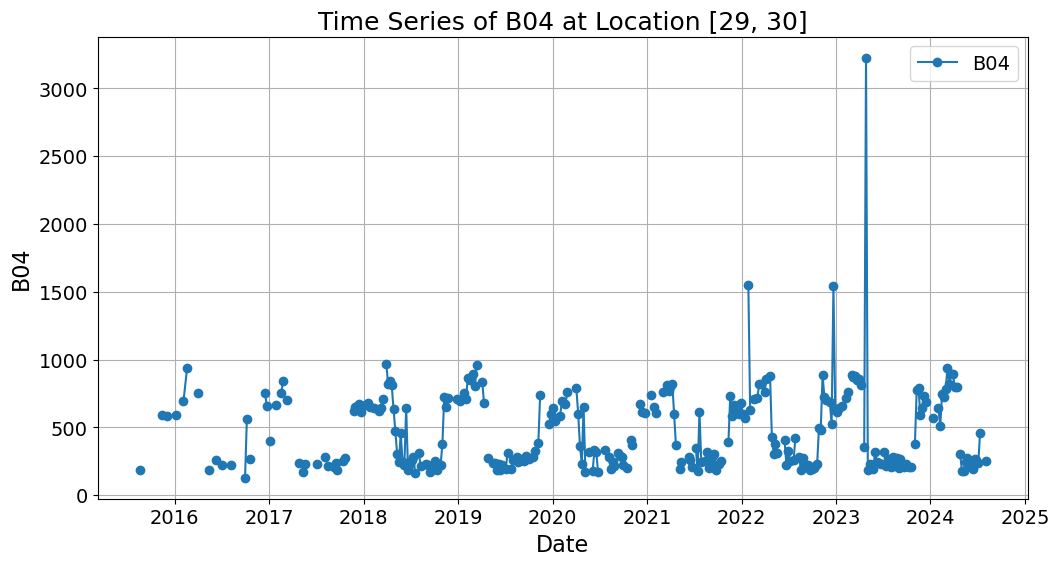

In [22]:
# Plotting the time series
plt.figure(figsize=(12, 6))

# Assuming 'sentle' is the variable storing NDVI, otherwise replace 'sentle' with the correct variable
ndvi_29_30.sentle.plot(label='B04', marker='o')  

plt.xlabel('Date')
plt.ylabel('B04')
plt.title('Time Series of B04 at Location [29, 30]')
plt.legend()
plt.grid(True)
plt.show()
